# Building a Purchase Propensity Model: the full notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USERNAME/purchase-propensity-model/blob/main/notebooks/Purchase_Propensity_Model.ipynb)

This notebook runs the whole series end to end on **synthetic data for a fictional retailer (BrightCart)**.
Every section matches a blog article, and every cell shows its own output.

**How to run it:** in Colab choose *Runtime > Run all* (about 10 minutes). To skip the slowest step,
set `RUN_WINDOW_EXPERIMENT = False` in the setup cell.

**How to save the results to GitHub:** run everything first, then choose *File > Save a copy in GitHub*.
Colab stores the outputs inside the notebook, so GitHub will show the tables and charts without anyone re-running it.

| Section | Step | Blog part |
| --- | --- | --- |
| 1 | Generate a dirty clickstream | 3 |
| 2 | Clean and build sessions | 3 |
| 3 | Target and features | 3 |
| 4 | Train three models | 4 |
| 5 | Deciles, lift and gain | 5 |
| 6 | Calibration | 5, 7 |
| 7 | SHAP explanations | 5, 9 |
| 8 | Propensity vs uplift | 6 |
| 9 | Drift monitoring | 6 |
| 10 | Build the campaign audience | 5, 6 |
| 11 | Observation window experiment | 2 |
| 12 | Concept diagrams | 1 to 3 |

## Setup
Install the libraries, create the folders, and define two small display helpers.

In [3]:
%pip install -q lightgbm shap pyarrow

import os, sys, warnings
warnings.filterwarnings("ignore")
os.makedirs("src", exist_ok=True)

RUN_WINDOW_EXPERIMENT = True     # about 4 minutes; set to False to skip section 11

import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

def show_img(name, width=820):
    display(Image(filename=f"images/{name}", width=width))

def show_csv(name, n=25):
    display(pd.read_csv(f"outputs/{name}").head(n))

## Shared settings: `config.py`
The windows, split dates and metric helpers live in one place, so every later step uses the same definitions.

In [9]:
%%writefile src/config.py
"""
Central configuration for the Purchase Propensity Model (PPM) series.

Every script imports from here so that the observation window, prediction
window and split dates are defined in exactly ONE place.
"""
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ---------- Paths ----------
ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
OUT_DIR = ROOT / "outputs"
IMG_DIR = ROOT / "images"
for _d in (DATA_DIR, MODEL_DIR, OUT_DIR, IMG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# ---------- Reproducibility ----------
SEED = 42

# ---------- Synthetic data settings (script 01) ----------
N_CUSTOMERS = 10_000
START_DATE = pd.Timestamp("2025-01-01")
N_DAYS = 210                     # Jan 1 -> Jul 29, 2025
CATEGORIES = ["Shoes", "Bags", "Electronics", "Fashion", "Home", "Beauty"]
PRODUCTS_PER_CATEGORY = 100

# ---------- Problem definition ----------
OBS_DAYS = 30                    # observation window: look back 30 days
PRED_DAYS = 7                    # prediction window: purchase in next 7 days
SESSION_GAP_MIN = 30             # inactivity threshold for sessionisation

# Weekly scoring dates (Mondays). T0 = "prediction point".
#   Features use events with  T0 - OBS_DAYS <= timestamp < T0
#   Target   uses events with T0 <= timestamp < T0 + PRED_DAYS
FIRST_SNAPSHOT = pd.Timestamp("2025-02-03")
LAST_SNAPSHOT = pd.Timestamp("2025-07-21")
SNAPSHOT_DATES = pd.date_range(FIRST_SNAPSHOT, LAST_SNAPSHOT, freq="7D")

# ---------- Time-based split (by prediction point T0) ----------
# The label window of every training snapshot ends on or before the first
# validation T0, so no label information leaks across the boundary.
TRAIN_END = pd.Timestamp("2025-04-28")      # last T0 in train
VAL_START = pd.Timestamp("2025-05-05")
VAL_END = pd.Timestamp("2025-05-26")
TEST_START = pd.Timestamp("2025-06-02")

# ---------- Modelling ----------
TARGET = "target"
ID_COLS = ["customer_id", "snapshot_date"]
TOP_FRACTION = 0.10              # "top 10%" audience for lift / campaigns

# Columns kept in the dataset but NOT given to the model.
# tenure_days grows with the calendar, so it drifts by construction (PSI flags it immediately).
EXCLUDE_FEATURES = ["tenure_days"]


Overwriting src/config.py


## Shared helpers: `utils.py`
The windows, split dates and metric helpers live in one place, so every later step uses the same definitions.

In [14]:
%%writefile src/utils.py
"""
Shared helpers used by scripts 04 to 11.

Keeping these in one file means every script measures things the same way:
the same train/validate/test split, the same definition of "lift", and so on.
"""

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

import config as cfg


# ----------------------------------------------------------------------------
# Loading the data and splitting it by TIME (never randomly -- see Part 2)
# ----------------------------------------------------------------------------
def load_dataset() -> pd.DataFrame:
    return pd.read_parquet(cfg.DATA_DIR / "features.parquet")


def feature_columns(df: pd.DataFrame) -> list[str]:
    """Every column except the ID columns, the target, and any feature we
    deliberately excluded (see config.EXCLUDE_FEATURES)."""
    not_a_feature = cfg.ID_COLS + [cfg.TARGET] + cfg.EXCLUDE_FEATURES
    return [c for c in df.columns if c not in not_a_feature]


def time_split(df: pd.DataFrame):
    """Split rows into train, validation and test by their prediction date,
    so the model is always tested on weeks it has never seen."""
    prediction_date = df["snapshot_date"]
    train = df[prediction_date <= cfg.TRAIN_END]
    validate = df[(prediction_date >= cfg.VAL_START) & (prediction_date <= cfg.VAL_END)]
    test = df[prediction_date >= cfg.TEST_START]
    return train, validate, test


# ----------------------------------------------------------------------------
# Ranking metrics: deciles, lift and cumulative gain
# ----------------------------------------------------------------------------
def decile_table(actual_outcome, predicted_score, n_bins: int = 10) -> pd.DataFrame:
    """
    Rank customers from highest score to lowest, then cut them into
    `n_bins` equal-size groups (deciles). For each group, compare its real
    purchase rate to the overall purchase rate -- that comparison is "lift".

    A good model should show a much higher purchase rate in decile 1
    (highest scores) than in decile 10 (lowest scores).
    """
    ranked = pd.DataFrame({"bought": np.asarray(actual_outcome), "score": np.asarray(predicted_score)})
    ranked = ranked.sort_values("score", ascending=False).reset_index(drop=True)
    ranked["decile"] = (np.arange(len(ranked)) * n_bins // len(ranked)) + 1     # decile 1 = highest scores
    overall_rate = ranked["bought"].mean()

    table = ranked.groupby("decile").agg(customers=("bought", "size"), buyers=("bought", "sum"),
                                         purchase_rate=("bought", "mean")).reset_index()
    table["lift"] = table["purchase_rate"] / overall_rate
    table["cumulative_share_of_buyers"] = table["buyers"].cumsum() / ranked["bought"].sum()
    return table


def lift_at(actual_outcome, predicted_score, top_fraction: float = 0.10) -> float:
    """How much better is the purchase rate in the TOP slice of scores,
    compared to the purchase rate across everyone?"""
    ranked = pd.DataFrame({"bought": np.asarray(actual_outcome), "score": np.asarray(predicted_score)})
    ranked = ranked.sort_values("score", ascending=False)
    top_n = max(1, int(len(ranked) * top_fraction))
    return ranked["bought"].iloc[:top_n].mean() / ranked["bought"].mean()


def capture_at(actual_outcome, predicted_score, top_fraction: float = 0.10) -> float:
    """Of ALL the customers who actually bought, what share were sitting
    in the top slice of the model's ranking?"""
    ranked = pd.DataFrame({"bought": np.asarray(actual_outcome), "score": np.asarray(predicted_score)})
    ranked = ranked.sort_values("score", ascending=False)
    top_n = max(1, int(len(ranked) * top_fraction))
    return ranked["bought"].iloc[:top_n].sum() / ranked["bought"].sum()


def gain_curve(actual_outcome, predicted_score):
    """Points for a cumulative gain chart: as we contact more and more
    customers (x, best score first), what share of all buyers have we
    reached so far (y)?"""
    ranked = pd.DataFrame({"bought": np.asarray(actual_outcome), "score": np.asarray(predicted_score)})
    ranked = ranked.sort_values("score", ascending=False)
    share_contacted = np.arange(1, len(ranked) + 1) / len(ranked)
    share_of_buyers_found = ranked["bought"].cumsum().to_numpy() / ranked["bought"].sum()
    return np.r_[0, share_contacted], np.r_[0, share_of_buyers_found]


def evaluate(actual_outcome, predicted_score) -> dict:
    """One dictionary with every metric we care about, so scripts can just
    call evaluate(...) once instead of computing each metric by hand."""
    p = np.clip(predicted_score, 0, 1)
    return {
        "roc_auc": roc_auc_score(actual_outcome, p),
        "pr_auc": average_precision_score(actual_outcome, p),
        "brier": brier_score_loss(actual_outcome, p),
        "lift_top10": lift_at(actual_outcome, p, 0.10),
        "capture_top10": capture_at(actual_outcome, p, 0.10),
        "mean_score": float(np.mean(p)),
        "base_rate": float(np.mean(actual_outcome)),
    }


# ----------------------------------------------------------------------------
# Calibration: turning a raw model score into a trustworthy probability
# ----------------------------------------------------------------------------
def _logit(p, eps: float = 1e-6):
    """The logit is the inverse of a sigmoid: it turns a 0-to-1 probability
    back into an unbounded number, which is what Platt scaling needs."""
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))


class PlattScaler:
    """
    Platt scaling fixes an over- or under-confident model with one smooth
    S-curve. Internally it is nothing more than a logistic regression with
    a single input: the logit of the raw score.
    """

    def fit(self, raw_scores, actual_outcome) -> "PlattScaler":
        x = _logit(raw_scores).reshape(-1, 1)
        self.model = LogisticRegression(C=1e6, max_iter=1000).fit(x, actual_outcome)
        return self

    def predict(self, raw_scores):
        x = _logit(raw_scores).reshape(-1, 1)
        return self.model.predict_proba(x)[:, 1]


# ----------------------------------------------------------------------------
# A consistent look for every chart in the series
# ----------------------------------------------------------------------------
def set_plot_style():
    import matplotlib.pyplot as plt
    plt.rcParams.update({
        "figure.dpi": 130, "savefig.dpi": 150, "savefig.bbox": "tight",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
        "axes.titlesize": 12, "axes.titleweight": "bold",
    })
    return plt


BLUE, ORANGE, GREEN, RED, GREY, PURPLE = "#2563eb", "#f59e0b", "#16a34a", "#dc2626", "#6b7280", "#7c3aed"


Overwriting src/utils.py


In [16]:
sys.path.insert(0, "src")
import config as cfg
print("Observation window:", cfg.OBS_DAYS, "days | Prediction window:", cfg.PRED_DAYS, "days")
print("Weekly prediction dates:", len(cfg.SNAPSHOT_DATES), "from", cfg.SNAPSHOT_DATES[0].date(), "to", cfg.SNAPSHOT_DATES[-1].date())

Observation window: 30 days | Prediction window: 7 days
Weekly prediction dates: 25 from 2025-02-03 to 2025-07-21


## 1.Generate sample clickstream data
,

*   We simulate about 1.3 million events for 10,000 customers
*   Then add the problems real logs have: duplicates, bots, missing timestamps and mixed time zones.
*   Generate dirty data to simulate real life scenario



Blog part 3.

Source file in the repo: `src/01_generate_synthetic_data.py`

In [17]:
"""
01 - Create a pretend clickstream for the fictional retailer BrightCart.

The goal here is NOT to be clever. It is to produce data that behaves like real
customer behaviour, using code a data analyst can read top to bottom.

The story we simulate, in plain English:
    - Every customer has a hidden "chance of buying" called intent. We never
      show this number anywhere; it just controls how the customer behaves.
    - Most days, most customers do nothing.
    - Sometimes a customer starts a short "shopping episode" that lasts a
      few days. During an episode they browse more, and some episodes end
      in a purchase.
    - Outside of an episode, a customer still browses occasionally and can
      make a rare "impulse" purchase without any build-up.

Because Part 3 of the series is about CLEANING data, this file deliberately
saves a messy version at the end: duplicate rows, a few bot accounts, some
missing timestamps, and timestamps written in two different time zones.

Output files (written to data/):
    raw_events.parquet   - the messy clickstream, one row per event
    customers.csv        - one row per customer (signup date, consent, etc.)

Run it with:
    python src/01_generate_synthetic_data.py

A more heavily-optimised (and much harder to read) version of this same idea
lives in src/advanced/ for comparison.
"""

import numpy as np
import pandas as pd

import config as cfg

# The event types we simulate, listed in the order they normally happen
# during a single visit. Later code relies on this order.
EVENT_TYPES = ["login", "page_view", "search", "product_view", "wishlist",
               "add_to_cart", "remove_from_cart", "checkout", "purchase"]

TRAFFIC_SOURCES = ["organic", "paid_search", "social", "email", "direct"]
TRAFFIC_SOURCE_WEIGHTS = [0.35, 0.25, 0.15, 0.10, 0.15]

# No human generates this many events by hand in one day.
# We use this later to build a few fake "bot" accounts.
BOT_EVENTS_PER_ACCOUNT = 3000


# ============================================================================
# STEP 1: give every customer a few hidden traits.
# These never appear in the saved file. They only control how the customer
# behaves in the simulation below.
# ============================================================================
def make_customer_traits(rng: np.random.Generator) -> pd.DataFrame:
    n = cfg.N_CUSTOMERS
    return pd.DataFrame({
        "intent": rng.beta(1.2, 6.0, n),            # baseline chance of ever buying (mean ~17%)
        "browsing_level": rng.gamma(2.0, 0.5, n),    # how often this customer visits at all
        "favourite_category": rng.integers(0, len(cfg.CATEGORIES), n),
        "prefers_mobile": rng.beta(4, 3, n),         # 0 = always desktop, 1 = always mobile
    })


def pick_hour_of_day(rng: np.random.Generator, n: int) -> np.ndarray:
    """Shoppers browse more in the evening than early morning. This is just
    a weighted random pick from hour 0 to 23, with evening hours weighted higher."""
    weights = np.array([1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 6, 5, 5, 5, 6, 7, 8, 10, 12, 12, 8, 4], dtype=float)
    return rng.choice(24, n, p=weights / weights.sum())


# ============================================================================
# STEP 2: simulate one single day for every customer.
# This is the heart of the file. It is one big function on purpose, so you
# can read it as a story: "here is what happens on day X".
# ============================================================================
def simulate_one_day(rng, traits, day_date, episode_days_left, will_buy_at_end) -> pd.DataFrame:
    """
    Returns a small DataFrame: one row per SESSION that happened today,
    with a count column for every event type (how many product views,
    how many cart adds, and so on, in that one session).

    `episode_days_left` and `will_buy_at_end` are numpy arrays, one entry
    per customer, that this function updates in place as episodes start
    and finish.
    """
    n_customers = len(traits)

    # --- 2a. Some customers who are not currently in an episode start one today.
    not_in_episode = episode_days_left == 0
    chance_of_starting_today = 0.004 + 0.02 * traits["intent"].to_numpy()
    starts_today = not_in_episode & (rng.random(n_customers) < chance_of_starting_today)

    n_new = int(starts_today.sum())
    episode_days_left[starts_today] = 2 + rng.poisson(4, n_new)          # episodes last 2 to ~10 days
    # the higher a customer's hidden intent, the more likely this episode ends in a sale
    will_buy_at_end[starts_today] = rng.random(n_new) < (0.25 + 0.60 * traits.loc[starts_today, "intent"].to_numpy())

    in_episode = episode_days_left > 0
    is_last_day_of_episode = episode_days_left == 1
    must_buy_today = is_last_day_of_episode & will_buy_at_end          # this customer WILL purchase today

    # --- 2b. Decide how many sessions (visits) each customer has today.
    # Customers currently in an episode browse much more than usual.
    expected_sessions = np.where(in_episode, 0.9 * np.sqrt(traits["browsing_level"]),
                                  0.05 * traits["browsing_level"])
    n_sessions = rng.poisson(expected_sessions)
    # A customer who must buy today is guaranteed at least one session.
    n_sessions = np.where(must_buy_today, np.maximum(n_sessions, 1), n_sessions)

    if n_sessions.sum() == 0:
        return pd.DataFrame(columns=["session_id", "customer_id", "session_start", "device",
                                      "traffic_source", "category", "product_id"] +
                                     [f"n_{e}" for e in EVENT_TYPES])

    # --- 2c. Build one row per session by repeating each customer by their session count.
    customer_row = np.repeat(np.arange(n_customers), n_sessions)
    session_in_episode = in_episode[customer_row]
    session_must_buy = must_buy_today[customer_row]
    n_today = len(customer_row)

    # --- 2d. Pick a device and traffic source for each session.
    is_mobile = rng.random(n_today) < traits["prefers_mobile"].to_numpy()[customer_row]
    device = np.where(is_mobile, "Mobile", np.where(rng.random(n_today) < 0.85, "Desktop", "Tablet"))
    traffic_source = rng.choice(TRAFFIC_SOURCES, n_today, p=TRAFFIC_SOURCE_WEIGHTS)

    # --- 2e. Pick what this session is "about": one category and one product.
    # A customer in an episode mostly looks at their favourite category.
    browses_favourite = rng.random(n_today) < np.where(session_in_episode, 0.85, 0.55)
    category_idx = np.where(browses_favourite, traits["favourite_category"].to_numpy()[customer_row],
                             rng.integers(0, len(cfg.CATEGORIES), n_today))
    category = np.array(cfg.CATEGORIES, dtype=object)[category_idx]
    product_id = "P" + pd.Series(category_idx * cfg.PRODUCTS_PER_CATEGORY
                                  + rng.integers(0, cfg.PRODUCTS_PER_CATEGORY, n_today) + 100).astype(str)

    # --- 2f. Decide how many of each event type happen in this session.
    # These are simple rules: more browsing and a higher chance of adding
    # to cart when the customer is in an episode, and guaranteed activity
    # on the day they are due to buy.
    n_page_view = 1 + rng.poisson(np.where(session_in_episode, 3.0, 1.0), n_today)
    n_search = rng.poisson(np.where(session_in_episode, 0.8, 0.3), n_today)
    n_login = (rng.random(n_today) < 0.5).astype(int)

    n_product_view = rng.poisson(np.where(session_in_episode, 5.0, 1.5), n_today)
    n_product_view = np.where(session_must_buy, np.maximum(n_product_view, 1), n_product_view)  # must look at something

    cart_add_chance = np.where(session_in_episode, 0.30, 0.05)
    n_add_to_cart = rng.binomial(n_product_view, cart_add_chance)
    n_add_to_cart = np.where(session_must_buy, np.maximum(n_add_to_cart, 1), n_add_to_cart)      # must have a cart

    n_remove_from_cart = rng.binomial(n_add_to_cart, 0.15)
    n_wishlist = rng.binomial(n_product_view, np.where(session_in_episode, 0.08, 0.03))

    checkout_chance = np.where(session_in_episode, 0.35, 0.10)
    checks_out = ((n_add_to_cart > 0) & (rng.random(n_today) < checkout_chance)) | session_must_buy
    n_checkout = checks_out.astype(int)

    # a customer NOT in an episode can still make a rare impulse purchase
    impulse_purchase = checks_out & ~session_in_episode & (rng.random(n_today) < 0.30)
    n_purchase = (session_must_buy | impulse_purchase).astype(int)

    hour = pick_hour_of_day(rng, n_today)
    session_start = day_date + pd.to_timedelta(hour * 3600 + rng.integers(0, 3600, n_today), unit="s")

    sessions_today = pd.DataFrame({
        "session_id": [f"C{c + 1:06d}_{day_date.strftime('%Y%m%d')}_{i}" for i, c in enumerate(customer_row)],
        "customer_id": "C" + pd.Series(customer_row + 1).astype(str).str.zfill(6),
        "session_start": session_start,
        "device": device, "traffic_source": traffic_source, "category": category, "product_id": product_id,
        "n_login": n_login, "n_page_view": n_page_view, "n_search": n_search,
        "n_product_view": n_product_view, "n_wishlist": n_wishlist, "n_add_to_cart": n_add_to_cart,
        "n_remove_from_cart": n_remove_from_cart, "n_checkout": n_checkout, "n_purchase": n_purchase,
    })

    # --- 2g. Close out episodes that just produced a purchase, and count down the rest.
    bought_today = np.zeros(n_customers, dtype=bool)
    bought_today[customer_row[n_purchase.astype(bool)]] = True
    episode_days_left[in_episode] -= 1
    episode_days_left[bought_today] = 0          # a purchase always ends the current episode early

    return sessions_today


# ============================================================================
# STEP 3: turn the session-level counts into one row per individual event.
# ============================================================================
def expand_sessions_into_events(sessions: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    """
    `sessions` has one row per session with columns like n_product_view,
    n_add_to_cart, and so on. This function "unpacks" those counts into
    one row per event, in the natural order events happen (EVENT_TYPES).
    """
    HAS_PRODUCT = {"product_view", "wishlist", "add_to_cart", "remove_from_cart", "checkout", "purchase"}
    HAS_CATEGORY = HAS_PRODUCT | {"page_view"}

    parts = []
    for event in EVENT_TYPES:                              # keep the natural visit order
        count_col = f"n_{event}"
        rows_with_this_event = sessions[sessions[count_col] > 0]
        how_many = rows_with_this_event[count_col]
        # repeat each session row once per event of this type it contains
        expanded = rows_with_this_event.loc[rows_with_this_event.index.repeat(how_many)].copy()
        expanded["event"] = event
        if event not in HAS_PRODUCT:
            expanded["product_id"] = None
        if event not in HAS_CATEGORY:
            expanded["category"] = None
        parts.append(expanded[["session_id", "customer_id", "session_start", "device",
                                "traffic_source", "category", "product_id", "event"]])

    events = pd.concat(parts, ignore_index=True)

    # Space events out inside their session: a small random gap (10-90 seconds)
    # after the previous event of the SAME session. groupby().cumcount() counts
    # "how many rows of this session came before this one", using the order the
    # rows already appear in (which is the visit order, because we processed
    # EVENT_TYPES above in that order) -- no extra sorting needed.
    gap_seconds = rng.integers(10, 90, len(events))
    is_first_event_of_session = (events.groupby("session_id").cumcount() == 0).to_numpy()
    gap_seconds[is_first_event_of_session] = 0
    seconds_into_session = pd.Series(gap_seconds).groupby(events["session_id"].to_numpy()).cumsum()
    events["timestamp"] = events["session_start"] + pd.to_timedelta(seconds_into_session.to_numpy(), unit="s")
    return events.drop(columns="session_start")


# ============================================================================
# STEP 4: make the data dirty on purpose, so Part 3 has real cleaning to do.
# ============================================================================
def add_bot_traffic(events: pd.DataFrame, rng: np.random.Generator, n_bots: int = 25) -> pd.DataFrame:
    """A handful of fake accounts that fire thousands of page views in a
    row -- the kind of noise a tracking pixel or crawler leaves behind."""
    bot_rows = []
    for i in range(n_bots):
        start_time = cfg.START_DATE + pd.to_timedelta(
            rng.integers(0, cfg.N_DAYS * 86400 - 4000, 1)[0], unit="s")
        bot_rows.append(pd.DataFrame({
            "customer_id": f"BOT_{i:04d}",
            "timestamp": start_time + pd.to_timedelta(np.arange(BOT_EVENTS_PER_ACCOUNT), unit="s"),
            "event": "page_view", "product_id": None, "category": "Shoes",
            "device": "Desktop", "traffic_source": "direct",
        }))
    return pd.concat([events] + bot_rows, ignore_index=True)


def make_data_dirty(events: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    events = add_bot_traffic(events, rng)

    # Duplicate about 1.5% of rows, as if a tracking tag fired twice.
    duplicate_rows = events.sample(frac=0.015, random_state=cfg.SEED)
    events = pd.concat([events, duplicate_rows], ignore_index=True)

    # Shuffle the file so it is NOT already sorted by customer or time,
    # which is how a real event log usually arrives.
    events = events.sample(frac=1.0, random_state=cfg.SEED).reset_index(drop=True)

    # Write 5% of timestamps in IST (UTC+5:30) and the rest in UTC, as
    # plain text -- exactly the kind of mixed time zone mess Part 3 fixes.
    logged_in_ist = rng.random(len(events)) < 0.05
    utc_text = events["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S") + "Z"
    ist_text = (events["timestamp"] + pd.Timedelta(hours=5, minutes=30)).dt.strftime("%Y-%m-%dT%H:%M:%S") + "+05:30"
    events["timestamp"] = np.where(logged_in_ist, ist_text, utc_text)

    # A few timestamps go missing and a few customer IDs get corrupted,
    # both common in real logging pipelines.
    events.loc[rng.random(len(events)) < 0.003, "timestamp"] = None
    bad_id = rng.random(len(events)) < 0.003
    events.loc[bad_id, "customer_id"] = rng.choice(["", "UNKNOWN", "null"], bad_id.sum())

    return events[["customer_id", "timestamp", "event", "product_id", "category", "device", "traffic_source"]]


def make_customer_master(rng: np.random.Generator) -> pd.DataFrame:
    """A simple customer table: signup date, marketing consent, last time
    we contacted them. Used later for the campaign eligibility rules."""
    n = cfg.N_CUSTOMERS
    return pd.DataFrame({
        "customer_id": "C" + pd.Series(np.arange(1, n + 1)).astype(str).str.zfill(6),
        "signup_date": cfg.START_DATE - pd.to_timedelta(rng.integers(30, 900, n), unit="D"),
        "marketing_consent": (rng.random(n) < 0.85).astype(int),
        "last_contact_date": cfg.LAST_SNAPSHOT - pd.to_timedelta(rng.integers(0, 30, n), unit="D"),
    })


# ============================================================================
# MAIN: run the simulation day by day, then make the result dirty and save it.
# ============================================================================
if __name__ == "__main__":
    rng = np.random.default_rng(cfg.SEED)
    traits = make_customer_traits(rng)

    episode_days_left = np.zeros(cfg.N_CUSTOMERS, dtype=int)   # 0 means "not currently in an episode"
    will_buy_at_end = np.zeros(cfg.N_CUSTOMERS, dtype=bool)

    all_sessions = []
    for day_number in range(cfg.N_DAYS):
        day_date = cfg.START_DATE + pd.Timedelta(days=day_number)
        sessions_today = simulate_one_day(rng, traits, day_date, episode_days_left, will_buy_at_end)
        if len(sessions_today):
            all_sessions.append(sessions_today)

    sessions = pd.concat(all_sessions, ignore_index=True)
    print(f"Simulated sessions : {len(sessions):,}")

    clean_events = expand_sessions_into_events(sessions, rng)
    print(f"Simulated events   : {len(clean_events):,} (before we make the file messy)")

    dirty_events = make_data_dirty(clean_events, rng)
    dirty_events.to_parquet(cfg.DATA_DIR / "raw_events.parquet", index=False)
    make_customer_master(rng).to_csv(cfg.DATA_DIR / "customers.csv", index=False)

    print(f"Raw (messy) events : {len(dirty_events):,}")
    print(dirty_events["event"].value_counts().to_string())
    print(f"\nSaved to {cfg.DATA_DIR}")


Simulated sessions : 174,881
Simulated events   : 1,418,172 (before we make the file messy)
Raw (messy) events : 1,515,570
event
page_view           584680
product_view        536474
add_to_cart         124897
search               91860
login                89053
wishlist             35405
checkout             26911
remove_from_cart     18937
purchase              7353

Saved to /content/data


**Results**

In [19]:
display(pd.read_parquet("data/raw_events.parquet").sample(8, random_state=1))

,customer_id,timestamp,event,product_id,category,device,traffic_source
1358811,C005115,2025-06-11T20:20:17Z,login,None,None,Mobile,email
1033542,C005427,2025-03-02T17:22:01Z,page_view,None,Beauty,Mobile,paid_search
844255,C004448,2025-04-09T17:32:56Z,wishlist,P626,Beauty,Desktop,paid_search
1332910,C003801,2025-07-17T12:25:03Z,product_view,P352,Electronics,Tablet,organic
912808,C007891,2025-02-02T02:04:09+05:30,page_view,None,Beauty,Mobile,email
1101852,C005065,2025-03-22T17:11:12Z,page_view,None,Home,Desktop,email
1075767,C005041,2025-03-22T16:40:34+05:30,product_view,P605,Beauty,Mobile,paid_search
936211,C008221,2025-03-07T20:05:38Z,product_view,P350,Electronics,Mobile,paid_search


## 2.Data cleaning and build sessions

*  Invalid rows, time zones, duplicates and bots are removed in that order
*  Then a 30-minute inactivity rule creates sessions

. Blog part 3.

Source file in the repo: `src/02_clean_and_sessionize.py`

In [21]:
"""
02 - Clean the raw clickstream and group events into sessions.

We fix problems in this order, and the order matters:
    1. Drop rows with no timestamp or a broken customer ID -- nothing else
       can be trusted about a row we cannot place in time or attribute.
    2. Convert every timestamp to one single time zone (UTC) -- you must
       do this BEFORE removing duplicates, or the same event logged in two
       time zones looks like two different events.
    3. Drop duplicate events (the same customer, time, event and product).
    4. Drop bot traffic (accounts with an impossible number of events).
    5. Sort by customer and time.
    6. Group events into sessions using a "30 minutes of silence" rule.

Output files (written to data/):
    events_clean.parquet   - one row per valid event, with a session_id
    sessions.parquet       - one row per session, summarised

It also writes outputs/cleaning_report.csv, which records exactly how many
rows each step removed.

Run it with:
    python src/02_clean_and_sessionize.py
"""

import pandas as pd

import config as cfg

# No real person can generate more events than this in a single day.
# Any customer ID that does is almost certainly a bot or a tracking bug.
MAX_HUMAN_EVENTS_PER_DAY = 500


def drop_invalid_rows(events: pd.DataFrame) -> pd.DataFrame:
    """Remove rows with no timestamp, and rows whose customer ID does not
    match our expected pattern (a real customer or a known bot ID)."""
    events = events[events["timestamp"].notna()]
    looks_like_a_real_id = events["customer_id"].fillna("").str.match(r"^(C\d{6}|BOT_\d{4})$")
    return events[looks_like_a_real_id]


def standardise_timestamps(events: pd.DataFrame) -> pd.DataFrame:
    """Convert every timestamp string (some UTC, some IST) into one plain
    UTC timestamp column, so events can be compared and sorted directly."""
    as_utc = pd.to_datetime(events["timestamp"], utc=True, format="ISO8601")
    return events.assign(timestamp=as_utc.dt.tz_convert("UTC").dt.tz_localize(None))


def drop_duplicate_events(events: pd.DataFrame) -> pd.DataFrame:
    """Two rows with the same customer, time, event type and product are
    almost certainly the same click logged twice."""
    return events.drop_duplicates(subset=["customer_id", "timestamp", "event", "product_id"])


def find_bot_customer_ids(events: pd.DataFrame) -> pd.Index:
    """A simple rule: count events per customer per calendar day, and flag
    any customer who crosses the human-possible limit on any single day."""
    one_day = events["timestamp"].dt.date
    events_per_customer_per_day = events.groupby(["customer_id", one_day]).size()
    too_many = events_per_customer_per_day[events_per_customer_per_day > MAX_HUMAN_EVENTS_PER_DAY]
    return too_many.index.get_level_values("customer_id").unique()


def build_sessions(events: pd.DataFrame) -> pd.DataFrame:
    """
    Group each customer's events into sessions: a new session starts
    whenever more than 30 minutes pass with no activity.

    Step by step:
      1. For every event, look at how long ago that SAME customer's
         previous event was (`time_since_last_event`).
      2. If that gap is bigger than 30 minutes (or this is the customer's
         very first event), mark it as the start of a new session.
      3. Number the sessions for each customer in order (1, 2, 3, ...) by
         counting how many "new session" flags came before it.
    """
    time_since_last_event = events.groupby("customer_id")["timestamp"].diff()
    starts_new_session = time_since_last_event.isna() | (time_since_last_event > pd.Timedelta(minutes=cfg.SESSION_GAP_MIN))
    session_number = starts_new_session.groupby(events["customer_id"]).cumsum()

    events = events.copy()
    events["session_id"] = events["customer_id"] + "_" + session_number.astype(str).str.zfill(4)
    return events


def summarise_sessions(events_with_sessions: pd.DataFrame) -> pd.DataFrame:
    """Collapse the event-level table into one row per session: when it
    started and ended, how many events it had, and its device/source."""
    by_session = events_with_sessions.groupby("session_id", sort=False)
    sessions = by_session.agg(
        customer_id=("customer_id", "first"),
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        n_events=("event", "size"),
        device=("device", "first"),
        traffic_source=("traffic_source", "first"),
    ).reset_index()
    sessions["duration_min"] = (sessions["session_end"] - sessions["session_start"]).dt.total_seconds() / 60
    return sessions


if __name__ == "__main__":
    raw_events = pd.read_parquet(cfg.DATA_DIR / "raw_events.parquet")
    row_counts = [("raw rows", len(raw_events))]

    events = drop_invalid_rows(raw_events)
    row_counts.append(("after dropping missing timestamps and bad customer IDs", len(events)))

    events = standardise_timestamps(events)          # must happen before de-duplication, see docstring

    events = drop_duplicate_events(events)
    row_counts.append(("after removing duplicate events", len(events)))

    bot_ids = find_bot_customer_ids(events)
    events = events[~events["customer_id"].isin(bot_ids)]
    row_counts.append((f"after removing bot traffic ({len(bot_ids)} bot IDs)", len(events)))

    events = events.sort_values(["customer_id", "timestamp"]).reset_index(drop=True)
    events = build_sessions(events)
    sessions = summarise_sessions(events)

    events.to_parquet(cfg.DATA_DIR / "events_clean.parquet", index=False)
    sessions.to_parquet(cfg.DATA_DIR / "sessions.parquet", index=False)

    report = pd.DataFrame(row_counts, columns=["step", "rows_remaining"])
    report["rows_removed"] = report["rows_remaining"].diff().fillna(0).abs().astype(int)
    report.to_csv(cfg.OUT_DIR / "cleaning_report.csv", index=False)

    print(report.to_string(index=False))
    print(f"\nSessions built: {len(sessions):,} (average {sessions['n_events'].mean():.1f} events per session)")


                                                  step  rows_remaining  rows_removed
                                              raw rows         1515570             0
after dropping missing timestamps and bad customer IDs         1506509          9061
                       after removing duplicate events         1484375         22134
               after removing bot traffic (25 bot IDs)         1409817         74558

Sessions built: 172,016 (average 8.2 events per session)


**Results**

In [22]:
show_csv("cleaning_report.csv")

,step,rows_remaining,rows_removed
0,raw rows,1515570,0
1,after dropping missing timestamps and bad cust...,1506509,9061
2,after removing duplicate events,1484375,22134
3,after removing bot traffic (25 bot IDs),1409817,74558


## 3.Data preparation - Feature engineering & target variable creation
One row per customer per Monday. Features use only events before that Monday, and the target looks at the next 7 days. Blog part 3.

Source file in the repo: `src/03_build_features.py`

In [23]:
"""
03 - Build the modelling table: one row per (customer, prediction date).

For every weekly prediction date T0:
    FEATURES come ONLY from events before T0   (the observation window)
    TARGET   comes ONLY from events at or after T0, up to 7 days later
             (the prediction window)

Nothing at or after T0 is ever allowed into a feature. That single rule is
what stops the model from "cheating" by peeking at the future.

The features are grouped into small, clearly named functions, one per
"feature family" (see Part 3 of the blog series):
    A. Recency     B. Frequency     C. Engagement     D. Funnel
    E. Affinity    F. Device/channel     G. Time of week     H. Profile

Each function takes a slice of events or sessions and returns a small
table indexed by customer_id. main() joins all of them together and adds
the target column.

Output: data/features.parquet

Run it with:
    python src/03_build_features.py
"""

import numpy as np
import pandas as pd

import config as cfg

ONE_DAY = pd.Timedelta(days=1)


def days_since(last_seen: pd.Series, t0: pd.Timestamp, value_if_never_seen: float) -> pd.Series:
    """How many days before t0 did this happen? If it never happened,
    use a large placeholder number instead of leaving it blank."""
    return ((t0 - last_seen) / ONE_DAY).clip(lower=0).fillna(value_if_never_seen)


# ----------------------------------------------------------------------------
# A. RECENCY: how recently did the customer do each kind of thing?
# ----------------------------------------------------------------------------
def recency_features(events: pd.DataFrame, sessions: pd.DataFrame, t0: pd.Timestamp, obs_days: int) -> pd.DataFrame:
    never_seen = obs_days + 1
    out = pd.DataFrame(index=pd.Index(sessions["customer_id"].unique(), name="customer_id"))
    out["days_since_last_visit"] = days_since(sessions.groupby("customer_id")["session_start"].max(), t0, never_seen)
    for label, event_name in [("product_view", "product_view"), ("cart_add", "add_to_cart"), ("checkout", "checkout")]:
        last_time = events.loc[events["event"] == event_name].groupby("customer_id")["timestamp"].max()
        out[f"days_since_last_{label}"] = days_since(last_time, t0, never_seen)
    last_purchase = events.loc[events["event"] == "purchase"].groupby("customer_id")["timestamp"].max()
    out["days_since_last_purchase"] = days_since(last_purchase, t0, never_seen)
    return out


# ----------------------------------------------------------------------------
# B. FREQUENCY: how often did the customer do each kind of thing?
# ----------------------------------------------------------------------------
def frequency_features(events: pd.DataFrame, events_last_7d: pd.DataFrame,
                       sessions: pd.DataFrame, sessions_last_7d: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=pd.Index(sessions["customer_id"].unique(), name="customer_id"))
    out["visits_30d"] = sessions.groupby("customer_id").size()
    out["visits_7d"] = sessions_last_7d.groupby("customer_id").size()

    event_column_name = {"product_view": "product_views", "add_to_cart": "add_to_carts", "search": "searches",
                          "wishlist": "wishlists", "checkout": "checkouts", "remove_from_cart": "remove_from_cart",
                          "purchase": "purchases"}
    counts_30d = events.groupby(["customer_id", "event"]).size().unstack(fill_value=0)
    counts_7d = events_last_7d.groupby(["customer_id", "event"]).size().unstack(fill_value=0)
    for event_name, column_name in event_column_name.items():
        out[f"{column_name}_30d"] = counts_30d.get(event_name)
        if event_name in ("product_view", "add_to_cart", "search", "wishlist", "checkout"):
            out[f"{column_name}_7d"] = counts_7d.get(event_name)
    return out


# ----------------------------------------------------------------------------
# C. ENGAGEMENT: how deep or focused was each visit?
# ----------------------------------------------------------------------------
def engagement_features(events: pd.DataFrame, sessions: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=pd.Index(sessions["customer_id"].unique(), name="customer_id"))
    by_customer = sessions.groupby("customer_id")
    out["avg_session_duration_min"] = by_customer["duration_min"].mean()
    out["events_per_session"] = by_customer["n_events"].mean()
    out["active_days_30d"] = events.groupby("customer_id")["timestamp"].apply(lambda ts: ts.dt.normalize().nunique())

    product_views = events[events["event"] == "product_view"]
    out["unique_products_viewed"] = product_views.groupby("customer_id")["product_id"].nunique()
    out["unique_categories_viewed"] = product_views.groupby("customer_id")["category"].nunique()
    return out


# ----------------------------------------------------------------------------
# D. FUNNEL: how far down visit -> view -> cart -> checkout did they get?
# These are simple ratios built from the frequency counts above.
# ----------------------------------------------------------------------------
def funnel_features(freq: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=freq.index)
    out["cart_rate_30d"] = freq["add_to_carts_30d"] / freq["product_views_30d"].replace(0, np.nan)
    out["cart_rate_7d"] = freq["add_to_carts_7d"] / freq["product_views_7d"].replace(0, np.nan)
    out["checkout_rate_30d"] = freq["checkouts_30d"] / freq["add_to_carts_30d"].replace(0, np.nan)
    # "is this week busier than the last month, on average?" -- a simple speeding-up signal
    out["view_momentum"] = freq["product_views_7d"] / (freq["product_views_30d"] + 1)
    return out


# ----------------------------------------------------------------------------
# E. AFFINITY: what does the customer seem interested in?
# ----------------------------------------------------------------------------
def affinity_features(events: pd.DataFrame) -> pd.DataFrame:
    product_views = events[events["event"] == "product_view"]
    out = pd.DataFrame(index=pd.Index(product_views["customer_id"].unique(), name="customer_id"))

    views_per_category = product_views.groupby(["customer_id", "category"]).size().unstack(fill_value=0)
    for category in cfg.CATEGORIES:
        out[f"views_in_{category.lower()}"] = views_per_category.get(category)
    out["top_category_share"] = views_per_category.max(axis=1) / views_per_category.sum(axis=1)

    views_per_product = product_views.groupby(["customer_id", "product_id"]).size()
    out["product_revisit_count"] = (views_per_product >= 2).groupby("customer_id").sum()
    out["max_views_same_product"] = views_per_product.groupby("customer_id").max()
    return out


# ----------------------------------------------------------------------------
# F. DEVICE AND CHANNEL: how does the customer usually shop?
# ----------------------------------------------------------------------------
def device_channel_features(sessions: pd.DataFrame) -> pd.DataFrame:
    device_share = pd.crosstab(sessions["customer_id"], sessions["device"], normalize="index")
    source_share = pd.crosstab(sessions["customer_id"], sessions["traffic_source"], normalize="index")
    out = pd.DataFrame(index=device_share.index)
    for device in ["Mobile", "Desktop", "Tablet"]:
        out[f"{device.lower()}_ratio"] = device_share.get(device)
    for source in ["organic", "paid_search", "social", "email", "direct"]:
        out[f"{source}_ratio"] = source_share.get(source)
    return out


# ----------------------------------------------------------------------------
# G. TIME OF WEEK: when does the customer usually shop?
# ----------------------------------------------------------------------------
def time_of_week_features(sessions: pd.DataFrame) -> pd.DataFrame:
    sessions = sessions.copy()
    hour = sessions["session_start"].dt.hour
    sessions["is_weekend"] = (sessions["session_start"].dt.dayofweek >= 5).astype(int)
    sessions["is_evening"] = hour.between(18, 23).astype(int)
    sessions["is_morning"] = hour.between(5, 11).astype(int)
    sessions["hour"] = hour

    by_customer = sessions.groupby("customer_id")
    out = pd.DataFrame(index=pd.Index(sessions["customer_id"].unique(), name="customer_id"))
    out["weekend_visit_ratio"] = by_customer["is_weekend"].mean()
    out["evening_visit_ratio"] = by_customer["is_evening"].mean()
    out["morning_visit_ratio"] = by_customer["is_morning"].mean()
    out["avg_hour_of_day"] = by_customer["hour"].mean()
    return out


# ----------------------------------------------------------------------------
# H. PROFILE: simple facts about the customer that do not come from events.
# Kept OUT of the model (see config.EXCLUDE_FEATURES) because tenure grows
# by one every day for every customer, so it drifts on its own over time.
# ----------------------------------------------------------------------------
def profile_features(customers: pd.DataFrame, t0: pd.Timestamp) -> pd.DataFrame:
    out = customers.set_index("customer_id")[["signup_date"]].copy()
    out["tenure_days"] = (t0 - out["signup_date"]).dt.days
    return out.drop(columns="signup_date")


# ----------------------------------------------------------------------------
# Put one prediction date together: features from before T0, target from after it.
# ----------------------------------------------------------------------------
def build_snapshot(events: pd.DataFrame, sessions: pd.DataFrame, customers: pd.DataFrame,
                   t0: pd.Timestamp, obs_days: int = cfg.OBS_DAYS) -> pd.DataFrame:
    window_start = t0 - obs_days * ONE_DAY
    last_7_days_start = t0 - 7 * ONE_DAY

    # Only events strictly BEFORE t0 are allowed into features.
    events_in_window = events[(events["timestamp"] >= window_start) & (events["timestamp"] < t0)]
    events_last_7d = events_in_window[events_in_window["timestamp"] >= last_7_days_start]
    sessions_in_window = sessions[(sessions["session_start"] >= window_start) & (sessions["session_start"] < t0)]
    sessions_last_7d = sessions_in_window[sessions_in_window["session_start"] >= last_7_days_start]

    # The modelling population is everyone who visited at least once in the
    # observation window. Some feature tables below cover a wider group
    # (profile_features knows every customer; affinity_features only knows
    # customers who viewed a product), so every table is reindexed onto this
    # exact population before joining -- otherwise a plain join would let the
    # widest table silently expand the population to everyone.
    population = pd.Index(sessions_in_window["customer_id"].unique(), name="customer_id")

    feature_tables = [
        recency_features(events_in_window, sessions_in_window, t0, obs_days),
        frequency_features(events_in_window, events_last_7d, sessions_in_window, sessions_last_7d),
        engagement_features(events_in_window, sessions_in_window),
        None,  # placeholder for funnel_features, filled in below once frequency is known
        affinity_features(events_in_window),
        device_channel_features(sessions_in_window),
        time_of_week_features(sessions_in_window),
        profile_features(customers, t0),
    ]
    feature_tables[3] = funnel_features(feature_tables[1])
    feature_tables = [table.reindex(population) for table in feature_tables]

    snapshot = pd.concat(feature_tables, axis=1)

    # Counts and ratios that are "not seen" should be zero, not blank.
    zero_when_missing = [c for c in snapshot.columns if any(key in c for key in
                         ["visits_", "_30d", "_7d", "views_in_", "unique_", "revisit", "max_views", "active_days"])]
    snapshot[zero_when_missing] = snapshot[zero_when_missing].fillna(0)
    snapshot = snapshot.fillna(0)

    # The target: did this customer purchase at or after T0, within the next 7 days?
    prediction_window_end = t0 + cfg.PRED_DAYS * ONE_DAY
    purchase_in_window = events.loc[(events["event"] == "purchase")
                                    & (events["timestamp"] >= t0)
                                    & (events["timestamp"] < prediction_window_end), "customer_id"].unique()
    snapshot[cfg.TARGET] = snapshot.index.isin(purchase_in_window).astype(int)

    snapshot.insert(0, "snapshot_date", t0)
    return snapshot.reset_index()


if __name__ == "__main__":
    events = pd.read_parquet(cfg.DATA_DIR / "events_clean.parquet")
    sessions = pd.read_parquet(cfg.DATA_DIR / "sessions.parquet")
    customers = pd.read_csv(cfg.DATA_DIR / "customers.csv", parse_dates=["signup_date"])

    all_snapshots = []
    for t0 in cfg.SNAPSHOT_DATES:
        snapshot = build_snapshot(events, sessions, customers, t0)
        all_snapshots.append(snapshot)
        print(f"{t0.date()}  rows={len(snapshot):>6,}  positives={snapshot[cfg.TARGET].sum():>4}  "
              f"rate={snapshot[cfg.TARGET].mean():.2%}")

    features = pd.concat(all_snapshots, ignore_index=True)
    features.to_parquet(cfg.DATA_DIR / "features.parquet", index=False)

    n_features = features.shape[1] - 3   # minus customer_id, snapshot_date, target
    print(f"\nDataset: {len(features):,} rows x {n_features} features | "
          f"overall purchase rate {features[cfg.TARGET].mean():.2%}")


2025-02-03  rows= 7,312  positives= 160  rate=2.19%
2025-02-10  rows= 7,349  positives= 129  rate=1.76%
2025-02-17  rows= 7,303  positives= 156  rate=2.14%
2025-02-24  rows= 7,379  positives= 142  rate=1.92%
2025-03-03  rows= 7,368  positives= 162  rate=2.20%
2025-03-10  rows= 7,320  positives= 168  rate=2.30%
2025-03-17  rows= 7,358  positives= 168  rate=2.28%
2025-03-24  rows= 7,400  positives= 188  rate=2.54%
2025-03-31  rows= 7,422  positives= 178  rate=2.40%
2025-04-07  rows= 7,454  positives= 186  rate=2.50%
2025-04-14  rows= 7,448  positives= 167  rate=2.24%
2025-04-21  rows= 7,415  positives= 147  rate=1.98%
2025-04-28  rows= 7,449  positives= 175  rate=2.35%
2025-05-05  rows= 7,450  positives= 151  rate=2.03%
2025-05-12  rows= 7,371  positives= 179  rate=2.43%
2025-05-19  rows= 7,340  positives= 182  rate=2.48%
2025-05-26  rows= 7,375  positives= 160  rate=2.17%
2025-06-02  rows= 7,372  positives= 171  rate=2.32%
2025-06-09  rows= 7,402  positives= 172  rate=2.32%
2025-06-16  

**Results**

In [24]:
df = pd.read_parquet("data/features.parquet")
display(df[["customer_id","snapshot_date","days_since_last_product_view","visits_7d","product_views_7d","add_to_carts_7d","checkouts_30d","mobile_ratio","target"]].sample(8, random_state=3).round(2))
print("Purchase rate by recent cart activity:")
display(df.groupby(df["add_to_carts_7d"] > 0)["target"].agg(["mean","size"]).rename(index={False:"no cart add in last 7d", True:"cart add in last 7d"}).round(4))

,customer_id,snapshot_date,days_since_last_product_view,visits_7d,product_views_7d,add_to_carts_7d,checkouts_30d,mobile_ratio,target
124925,C009197,2025-05-26,10.24,0.0,0.0,0.0,0,0.50,0
173336,C004625,2025-07-14,10.59,0.0,0.0,0.0,0,0.67,0
124108,C008063,2025-05-26,0.72,1.0,6.0,3.0,1,0.33,1
155009,C009869,2025-06-23,4.62,1.0,3.0,0.0,0,0.00,0
104505,C001497,2025-05-12,2.29,1.0,1.0,0.0,0,1.00,0
66046,C009778,2025-03-31,22.13,0.0,0.0,0.0,1,1.00,0
118086,C009933,2025-05-19,9.22,0.0,0.0,0.0,0,1.00,0
134479,C002178,2025-06-09,2.71,1.0,1.0,0.0,0,0.67,0


Purchase rate by recent cart activity:


,mean,size
add_to_carts_7d,,
no cart add in last 7d,0.0095,161704
cart add in last 7d,0.1161,22984


## 4.Model training


*   Train 3 models based on a time-based split
*   Models used: Logistic regression, random forest and LightGBM
*   Model is trained on the oldest weeks and compared on a validation block.

Blog part 4.

Source file in the repo: `src/04_train_models.py`

train:  95,977 rows | 2025-02-03 -> 2025-04-28 | buyers 2.22%
val  :  29,536 rows | 2025-05-05 -> 2025-05-26 | buyers 2.28%
test :  59,175 rows | 2025-06-02 -> 2025-07-21 | buyers 2.38%

Validation results (base rate = 2.28%)
              model  roc_auc  pr_auc  brier  lift_top10  capture_top10  mean_score  base_rate
logistic_regression   0.7952  0.1815 0.1489      6.4448         0.6443      0.3511     0.0228
      random_forest   0.8018  0.2193 0.0880      6.5787         0.6577      0.2681     0.0228
           lightgbm   0.7969  0.2216 0.0287      6.6383         0.6637      0.0860     0.0228


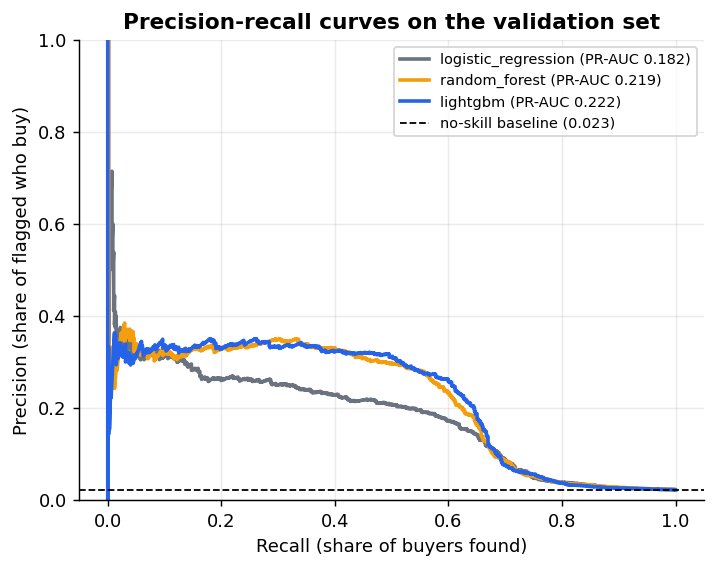

In [25]:
"""
04 - Train three models and compare them on a time-based split.

We train three models of increasing complexity, so we can see whether the
extra complexity actually buys us anything:
    1. Logistic regression - a simple, explainable baseline
    2. Random forest       - many decision trees, averaged together
    3. LightGBM            - gradient-boosted trees, usually the strongest
                             on tabular data like ours

The data is imbalanced (only about 2% of rows are buyers), so every model
is given "class weights": mistakes on a real buyer count for more than
mistakes on a non-buyer. This helps the model pay attention to the rare
class, but it also makes the raw scores over-confident, which is exactly
the problem Part 5 (calibration) fixes.

Outputs:
    models/*.joblib                      - the trained models and feature list
    outputs/model_comparison.csv         - validation metrics, side by side
    outputs/predictions_val.parquet      - every model's score on validation rows
    outputs/predictions_test.parquet     - every model's score on test rows
    images/ppm-05-model-comparison-pr-curves.png

Run it with:
    python src/04_train_models.py
"""

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import config as cfg
import utils


def build_models(positive_class_weight: float) -> dict:
    """Return the three untrained models in a dictionary, so the rest of
    the script can just loop over them instead of repeating code three times."""
    return {
        "logistic_regression": make_pipeline(
            StandardScaler(),                              # logistic regression needs features on a similar scale
            LogisticRegression(C=0.3, max_iter=3000, class_weight="balanced")),
        "random_forest": RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=30, max_features="sqrt",
            class_weight="balanced_subsample", n_jobs=-1, random_state=cfg.SEED),
        "lightgbm": lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=60,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5.0,
            scale_pos_weight=positive_class_weight, random_state=cfg.SEED, n_jobs=-1, verbose=-1),
    }


def train_and_score_one_model(name, model, X_train, y_train, X_val, X_test):
    """Fit one model, then return its predicted probabilities on the
    validation and test sets (we do not look at test metrics yet -- that
    happens in script 05, on the untouched test set)."""
    model.fit(X_train, y_train)
    val_scores = model.predict_proba(X_val)[:, 1]
    test_scores = model.predict_proba(X_test)[:, 1]
    joblib.dump(model, cfg.MODEL_DIR / f"{name}.joblib")
    return val_scores, test_scores


def plot_precision_recall_curves(results_by_model, y_val, path):
    """One chart with all three models' precision-recall curves, so it is
    easy to see which model trades precision for recall more gracefully."""
    plt = utils.set_plot_style()
    colors = {"logistic_regression": utils.GREY, "random_forest": utils.ORANGE, "lightgbm": utils.BLUE}

    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    for name, (val_scores, metrics) in results_by_model.items():
        precision, recall, _ = precision_recall_curve(y_val, val_scores)
        ax.plot(recall, precision, color=colors[name], lw=2, label=f"{name} (PR-AUC {metrics['pr_auc']:.3f})")
    ax.axhline(y_val.mean(), color="black", ls="--", lw=1, label=f"no-skill baseline ({y_val.mean():.3f})")
    ax.set(xlabel="Recall (share of buyers found)", ylabel="Precision (share of flagged who buy)",
           title="Precision-recall curves on the validation set", ylim=(0, 1))
    ax.legend(loc="upper right", fontsize=8)
    fig.savefig(path)


if __name__ == "__main__":
    data = utils.load_dataset()
    feature_names = utils.feature_columns(data)
    train, val, test = utils.time_split(data)

    for split_name, split_data in [("train", train), ("val", val), ("test", test)]:
        print(f"{split_name:5s}: {len(split_data):>7,} rows | "
              f"{split_data['snapshot_date'].min().date()} -> {split_data['snapshot_date'].max().date()} | "
              f"buyers {split_data[cfg.TARGET].mean():.2%}")

    X_train, y_train = train[feature_names], train[cfg.TARGET]
    X_val, y_val = val[feature_names], val[cfg.TARGET]
    X_test = test[feature_names]

    # A moderate class weight: the square root of the imbalance ratio.
    # Using the FULL ratio tends to overcorrect and hurt ranking quality.
    imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
    models = build_models(positive_class_weight=float(np.sqrt(imbalance_ratio)))

    results_by_model = {}
    val_predictions = val[cfg.ID_COLS + [cfg.TARGET]].copy()
    test_predictions = test[cfg.ID_COLS + [cfg.TARGET]].copy()

    for name, model in models.items():
        val_scores, test_scores = train_and_score_one_model(name, model, X_train, y_train, X_val, X_test)
        val_predictions[f"p_{name}"] = val_scores
        test_predictions[f"p_{name}"] = test_scores
        results_by_model[name] = (val_scores, utils.evaluate(y_val, val_scores))

    plot_precision_recall_curves(results_by_model, y_val, cfg.IMG_DIR / "ppm-05-model-comparison-pr-curves.png")

    comparison_table = pd.DataFrame(
        [{"model": name, **metrics} for name, (_, metrics) in results_by_model.items()]).round(4)
    comparison_table.to_csv(cfg.OUT_DIR / "model_comparison.csv", index=False)
    val_predictions.to_parquet(cfg.OUT_DIR / "predictions_val.parquet", index=False)
    test_predictions.to_parquet(cfg.OUT_DIR / "predictions_test.parquet", index=False)
    joblib.dump(feature_names, cfg.MODEL_DIR / "feature_list.joblib")

    print(f"\nValidation results (base rate = {y_val.mean():.2%})")
    print(comparison_table.to_string(index=False))


**Results**

,model,roc_auc,pr_auc,brier,lift_top10,capture_top10,mean_score,base_rate
0,logistic_regression,0.7952,0.1815,0.1489,6.4448,0.6443,0.3511,0.0228
1,random_forest,0.8018,0.2193,0.0880,6.5787,0.6577,0.2681,0.0228
2,lightgbm,0.7969,0.2216,0.0287,6.6383,0.6637,0.0860,0.0228


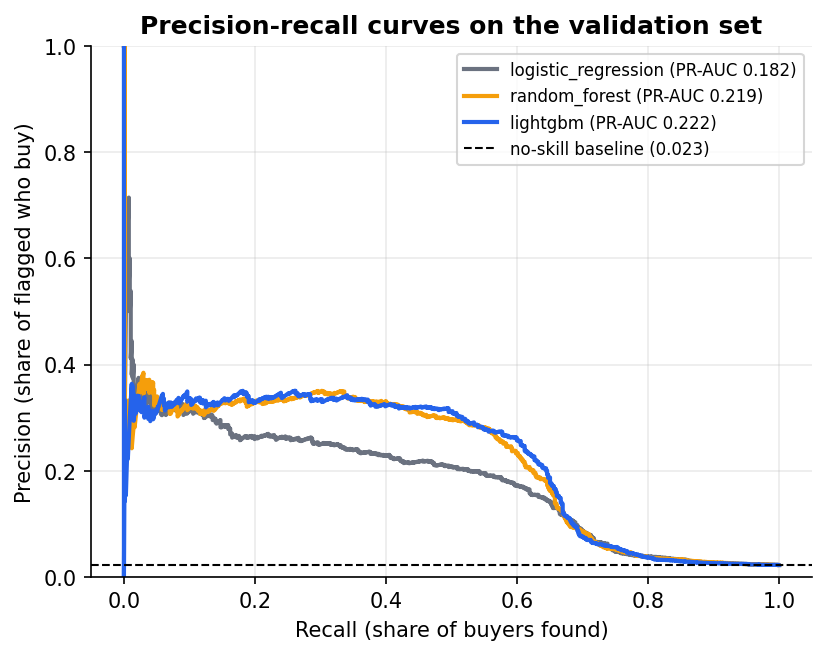

In [26]:
show_csv("model_comparison.csv")
show_img("ppm-05-model-comparison-pr-curves.png", 620)

## 5.Model testing
*  Evaluate on the untouched test set: deciles, lift and gain
*  Customers are ranked by score, cut into ten equal groups, and their real purchase rates are compared


Blog part 5.

Source file in the repo: `src/05_evaluate_lift_gain.py`

TEST metrics (base rate 2.38%)
              model  roc_auc  pr_auc  brier  lift_top10  capture_top10  mean_score  base_rate
logistic_regression   0.8011  0.1590 0.1501      6.2089         0.6208      0.3527     0.0238
      random_forest   0.7975  0.2147 0.0888      6.4215         0.6421      0.2687     0.0238
           lightgbm   0.8005  0.2254 0.0295      6.4215         0.6421      0.0863     0.0238

Decile table for lightgbm
 decile  customers  buyers  purchase_rate  lift  cumulative_share_of_buyers
      1       5918     906          0.153 6.420                       0.642
      2       5917      73          0.012 0.517                       0.694
      3       5918      61          0.010 0.432                       0.737
      4       5917      41          0.007 0.291                       0.766
      5       5918      65          0.011 0.461                       0.812
      6       5917      51          0.009 0.361                       0.848
      7       5918      65        

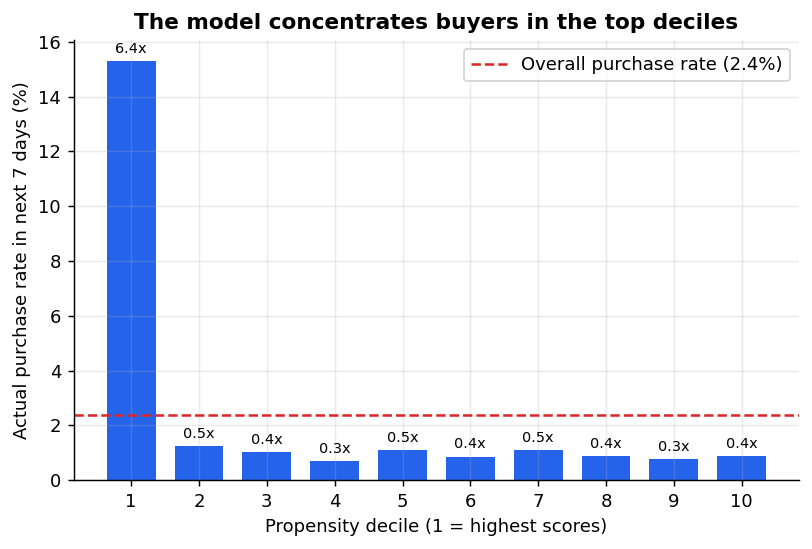

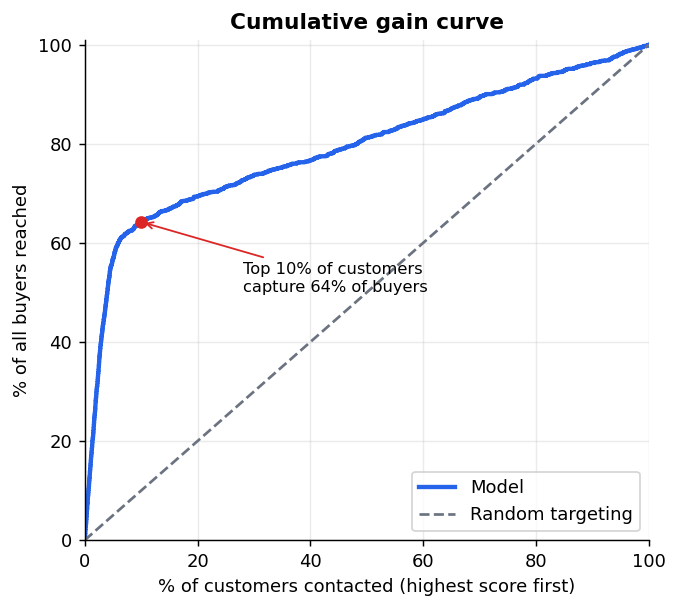

In [28]:
"""
05 - Evaluate on the untouched TEST set: deciles, lift and cumulative gain.

This is the first time in the pipeline we look at the test set's outcomes.
Everything up to now (choosing model settings, comparing models) used only
the validation set, so this evaluation is not flattered by any tuning.

The core idea: rank every customer by their propensity score, cut the
ranking into 10 equal-size groups (deciles), and compare each group's real
purchase rate to the overall rate. A useful model concentrates buyers in
the top few deciles.

Outputs:
    outputs/test_metrics.csv        - headline metrics for all three models
    outputs/decile_table_test.csv   - the decile breakdown for our chosen model
    images/ppm-06-decile-purchase-rate.png
    images/ppm-07-cumulative-gain.png

Run it with:
    python src/05_evaluate_lift_gain.py
"""

import numpy as np
import pandas as pd

import config as cfg
import utils

MODEL_TO_INSPECT = "lightgbm"


def plot_purchase_rate_by_decile(decile_table, overall_rate, path):
    plt = utils.set_plot_style()
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    bars = ax.bar(decile_table["decile"], decile_table["purchase_rate"] * 100, color=utils.BLUE, width=0.72)
    ax.axhline(overall_rate * 100, color=utils.RED, ls="--", lw=1.4, label=f"Overall purchase rate ({overall_rate:.1%})")
    for bar, lift in zip(bars, decile_table["lift"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{lift:.1f}x", ha="center", fontsize=8)
    ax.set(xlabel="Propensity decile (1 = highest scores)", ylabel="Actual purchase rate in next 7 days (%)",
           title="The model concentrates buyers in the top deciles", xticks=range(1, 11))
    ax.legend()
    fig.savefig(path)


def plot_cumulative_gain(actual_outcome, predicted_score, top_fraction, path):
    plt = utils.set_plot_style()
    fig, ax = plt.subplots(figsize=(5.6, 5.0))

    x, y = utils.gain_curve(actual_outcome, predicted_score)
    ax.plot(x * 100, y * 100, color=utils.BLUE, lw=2.4, label="Model")
    ax.plot([0, 100], [0, 100], color=utils.GREY, ls="--", label="Random targeting")

    captured = utils.capture_at(actual_outcome, predicted_score, top_fraction)
    ax.scatter([top_fraction * 100], [captured * 100], color=utils.RED, zorder=5)
    ax.annotate(f"Top {top_fraction:.0%} of customers\ncapture {captured:.0%} of buyers",
               (top_fraction * 100, captured * 100), xytext=(28, captured * 100 - 14),
               arrowprops=dict(arrowstyle="->", color=utils.RED), fontsize=9)

    ax.set(xlabel="% of customers contacted (highest score first)", ylabel="% of all buyers reached",
           title="Cumulative gain curve", xlim=(0, 100), ylim=(0, 101))
    ax.legend(loc="lower right")
    fig.savefig(path)


if __name__ == "__main__":
    predictions = pd.read_parquet(cfg.OUT_DIR / "predictions_test.parquet")
    actual_outcome = predictions[cfg.TARGET].to_numpy()
    model_names = [column[2:] for column in predictions.columns if column.startswith("p_")]

    # --- headline metrics for every model, on the untouched test set ------------------
    metrics_table = pd.DataFrame(
        [{"model": name, **utils.evaluate(actual_outcome, predictions[f"p_{name}"])} for name in model_names]
    ).round(4)
    metrics_table.to_csv(cfg.OUT_DIR / "test_metrics.csv", index=False)
    print(f"TEST metrics (base rate {actual_outcome.mean():.2%})")
    print(metrics_table.to_string(index=False))

    # --- decile breakdown for our chosen model -----------------------------------------
    chosen_score = predictions[f"p_{MODEL_TO_INSPECT}"].to_numpy()
    decile_table = utils.decile_table(actual_outcome, chosen_score)
    decile_table.round(4).to_csv(cfg.OUT_DIR / "decile_table_test.csv", index=False)
    print(f"\nDecile table for {MODEL_TO_INSPECT}")
    print(decile_table.round(3).to_string(index=False))

    plot_purchase_rate_by_decile(decile_table, actual_outcome.mean(), cfg.IMG_DIR / "ppm-06-decile-purchase-rate.png")
    plot_cumulative_gain(actual_outcome, chosen_score, cfg.TOP_FRACTION, cfg.IMG_DIR / "ppm-07-cumulative-gain.png")

    # --- precision and recall if we only contact the top slice --------------------------
    top_n = int(len(chosen_score) * cfg.TOP_FRACTION)
    top_customers = np.argsort(-chosen_score)[:top_n]
    precision = actual_outcome[top_customers].mean()
    recall = actual_outcome[top_customers].sum() / actual_outcome.sum()
    print(f"\nTop {cfg.TOP_FRACTION:.0%} audience: {top_n:,} customers | precision {precision:.1%} | "
          f"recall {recall:.1%} | lift {precision / actual_outcome.mean():.1f}x")

    # --- the accuracy trap: a model that never flags anyone still looks "accurate" ------
    print(f"'Nobody buys' accuracy: {(actual_outcome == 0).mean():.2%}  (looks great, finds 0 buyers)")


**Results**

,model,roc_auc,pr_auc,brier,lift_top10,capture_top10,mean_score,base_rate
0,logistic_regression,0.8011,0.1590,0.1501,6.2089,0.6208,0.3527,0.0238
1,random_forest,0.7975,0.2147,0.0888,6.4215,0.6421,0.2687,0.0238
2,lightgbm,0.8005,0.2254,0.0295,6.4215,0.6421,0.0863,0.0238


,decile,customers,buyers,purchase_rate,lift,cumulative_share_of_buyers
0,1,5918,906,0.1531,6.4204,0.6421
1,2,5917,73,0.0123,0.5174,0.6938
2,3,5918,61,0.0103,0.4323,0.7371
3,4,5917,41,0.0069,0.2906,0.7661
4,5,5918,65,0.0110,0.4606,0.8122
5,6,5917,51,0.0086,0.3615,0.8483
6,7,5918,65,0.0110,0.4606,0.8944
7,8,5917,52,0.0088,0.3686,0.9313
8,9,5918,45,0.0076,0.3189,0.9631
9,10,5917,52,0.0088,0.3686,1.0000


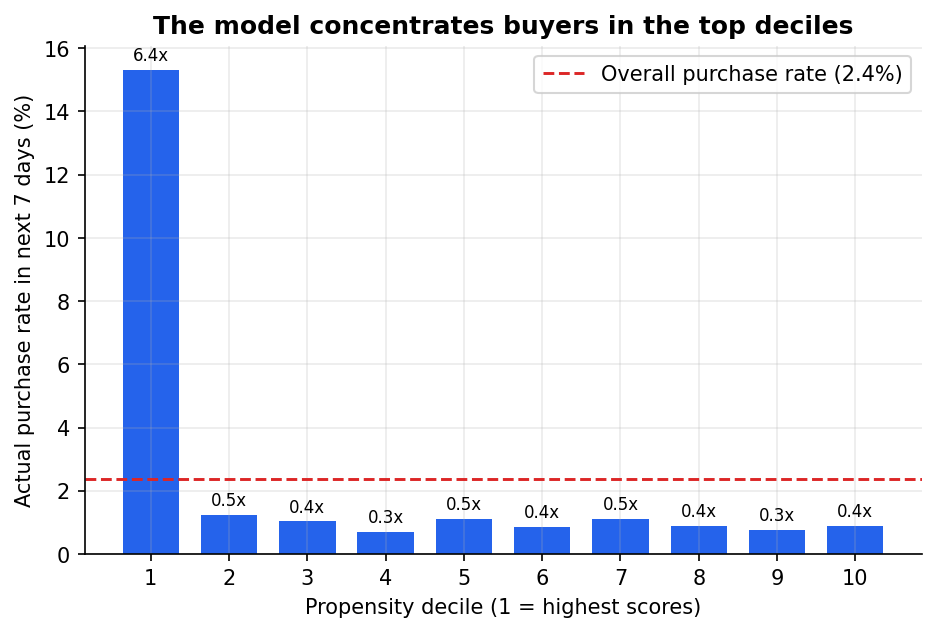

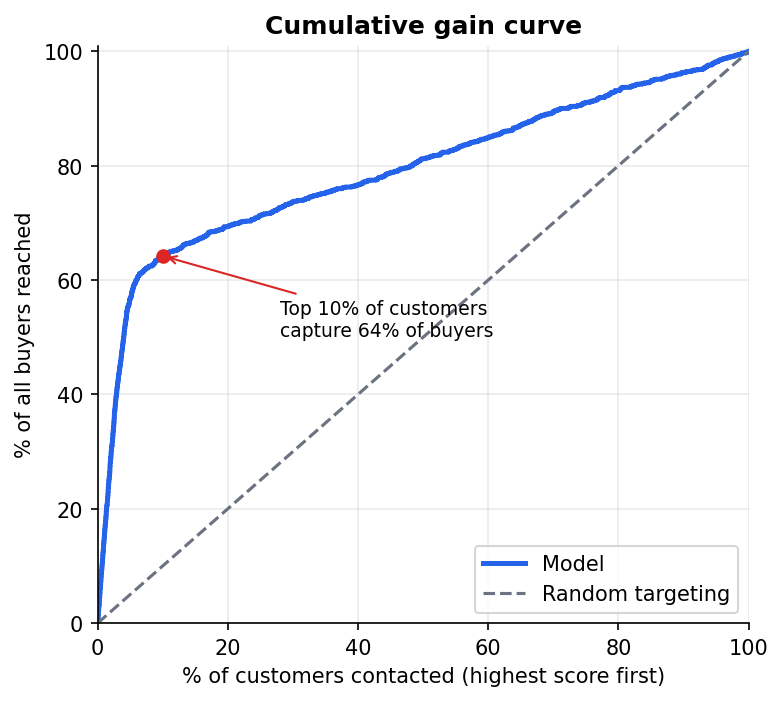

In [29]:
show_csv("test_metrics.csv")
show_csv("decile_table_test.csv")
show_img("ppm-06-decile-purchase-rate.png", 700)
show_img("ppm-07-cumulative-gain.png", 520)

## 6.Model calibration of the probabilities
*  The class-weighted model ranks well but over-predicts.
*  Platt scaling and isotonic regression fix that, fitted on validation data and judged on test data.

Blog parts 5 and 7.

Source file in the repo: `src/06_calibration.py`

            version  brier    ece  roc_auc  mean_predicted  observed_rate  lift_top10
          raw model 0.0295 0.0624   0.8005          0.0863         0.0238      6.4215
      Platt scaling 0.0198 0.0030   0.8005          0.0229         0.0238      6.4215
isotonic regression 0.0198 0.0015   0.7999          0.0230         0.0238      6.4215


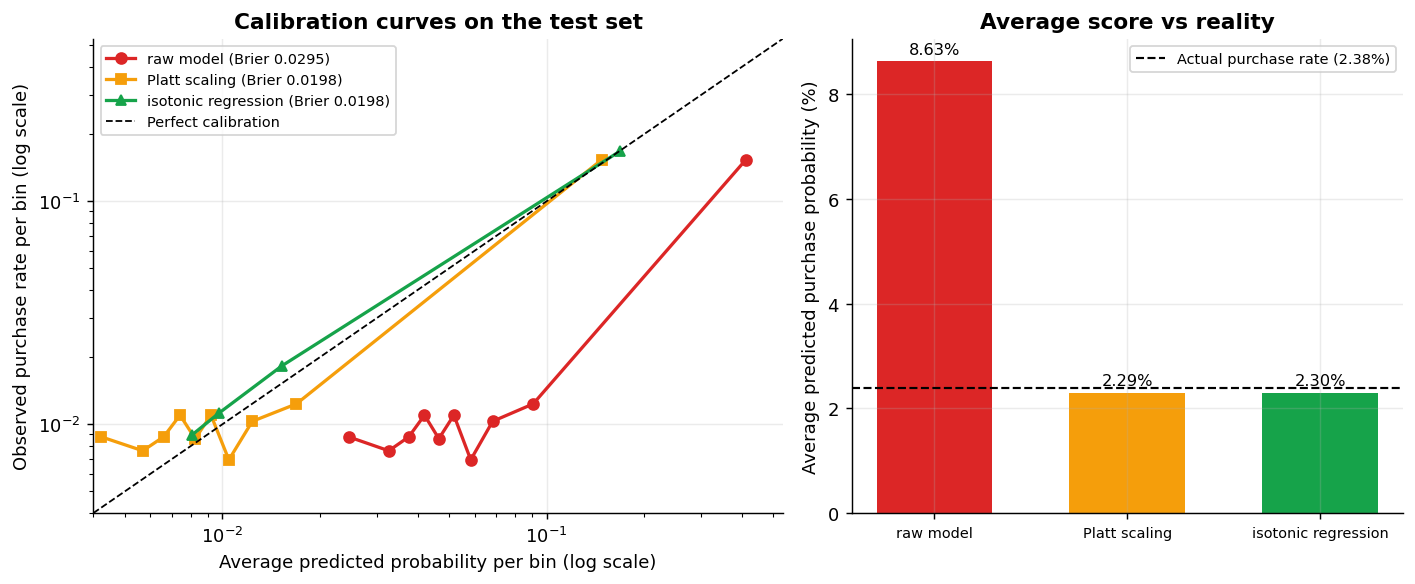

In [30]:
"""
06 - Calibrate the LightGBM scores with Platt scaling and isotonic regression.

The class-weighted model from script 04 ranks customers well, but its raw
scores are inflated: its average predicted probability is much higher than
the real purchase rate. That is fine for ranking (deciding WHO to contact),
but not fine if marketing wants to plug the number into a budget.

Two standard fixes:
    Platt scaling       - reshapes the score with one smooth S-curve
    Isotonic regression - reshapes it with a flexible, step-like curve

The golden rule: fit the calibrator on the VALIDATION set (never on the
data the model itself trained on), then judge the result on the TEST set.

Outputs:
    models/platt.joblib, models/isotonic.joblib
    outputs/calibration_results.csv
    images/ppm-10-calibration-curves.png

Run it with:
    python src/06_calibration.py
"""

import joblib
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score

import config as cfg
import utils

MODEL_TO_CALIBRATE = "lightgbm"


def expected_calibration_error(actual_outcome, predicted_score, n_bins: int = 10) -> float:
    """Split customers into bins of similar predicted score, then average
    the gap between 'what we predicted' and 'what actually happened' in
    each bin. Zero means perfectly calibrated."""
    observed_rate, predicted_rate = calibration_curve(actual_outcome, predicted_score, n_bins=n_bins, strategy="quantile")
    return float(np.mean(np.abs(observed_rate - predicted_rate)))


def plot_calibration_curves(scores_by_version, actual_outcome, path):
    plt = utils.set_plot_style()
    style = {"raw model": (utils.RED, "o"), "Platt scaling": (utils.ORANGE, "s"), "isotonic regression": (utils.GREEN, "^")}

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})

    # left panel: predicted probability vs what actually happened, per bin
    ax = axes[0]
    highest_value = 0
    for name, score in scores_by_version.items():
        observed_rate, predicted_rate = calibration_curve(actual_outcome, score, n_bins=10, strategy="quantile")
        color, marker = style[name]
        brier = brier_score_loss(actual_outcome, score)
        ax.plot(predicted_rate, observed_rate, color=color, marker=marker, lw=1.8, label=f"{name} (Brier {brier:.4f})")
        highest_value = max(highest_value, predicted_rate.max(), observed_rate.max())
    axis_limit = highest_value * 1.3
    lower_limit = 0.004
    ax.plot([lower_limit, axis_limit], [lower_limit, axis_limit], color="black", ls="--", lw=1, label="Perfect calibration")
    ax.set(xscale="log", yscale="log", xlim=(lower_limit, axis_limit), ylim=(lower_limit, axis_limit),
           xlabel="Average predicted probability per bin (log scale)",
           ylabel="Observed purchase rate per bin (log scale)", title="Calibration curves on the test set")
    ax.legend(fontsize=8, loc="upper left")

    # right panel: one number per version -- the average predicted probability
    ax = axes[1]
    labels = list(scores_by_version)
    average_predictions = [scores_by_version[name].mean() * 100 for name in labels]
    colors = [style[name][0] for name in labels]
    ax.bar(labels, average_predictions, color=colors, width=0.6)
    ax.axhline(actual_outcome.mean() * 100, color="black", ls="--", lw=1.2,
              label=f"Actual purchase rate ({actual_outcome.mean():.2%})")
    for i, value in enumerate(average_predictions):
        ax.text(i, value + 0.15, f"{value:.2f}%", ha="center", fontsize=9)
    ax.set(ylabel="Average predicted purchase probability (%)", title="Average score vs reality")
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(path)


if __name__ == "__main__":
    val = pd.read_parquet(cfg.OUT_DIR / "predictions_val.parquet")
    test = pd.read_parquet(cfg.OUT_DIR / "predictions_test.parquet")
    val_score, val_outcome = val[f"p_{MODEL_TO_CALIBRATE}"].to_numpy(), val[cfg.TARGET].to_numpy()
    test_score, test_outcome = test[f"p_{MODEL_TO_CALIBRATE}"].to_numpy(), test[cfg.TARGET].to_numpy()

    # Fit both calibrators on VALIDATION data only.
    platt = utils.PlattScaler().fit(val_score, val_outcome)
    isotonic = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip").fit(val_score, val_outcome)
    joblib.dump(platt, cfg.MODEL_DIR / "platt.joblib")
    joblib.dump(isotonic, cfg.MODEL_DIR / "isotonic.joblib")

    # Judge all three versions on TEST data.
    scores_by_version = {
        "raw model": test_score,
        "Platt scaling": platt.predict(test_score),
        "isotonic regression": isotonic.predict(test_score),
    }
    results = pd.DataFrame([{
        "version": name,
        "brier": brier_score_loss(test_outcome, score),
        "ece": expected_calibration_error(test_outcome, score),
        "roc_auc": roc_auc_score(test_outcome, score),
        "mean_predicted": score.mean(),
        "observed_rate": test_outcome.mean(),
        "lift_top10": utils.lift_at(test_outcome, score, 0.10),
    } for name, score in scores_by_version.items()]).round(4)
    results.to_csv(cfg.OUT_DIR / "calibration_results.csv", index=False)
    print(results.to_string(index=False))

    plot_calibration_curves(scores_by_version, test_outcome, cfg.IMG_DIR / "ppm-10-calibration-curves.png")


**Results**

,version,brier,ece,roc_auc,mean_predicted,observed_rate,lift_top10
0,raw model,0.0295,0.0624,0.8005,0.0863,0.0238,6.4215
1,Platt scaling,0.0198,0.0030,0.8005,0.0229,0.0238,6.4215
2,isotonic regression,0.0198,0.0015,0.7999,0.0230,0.0238,6.4215


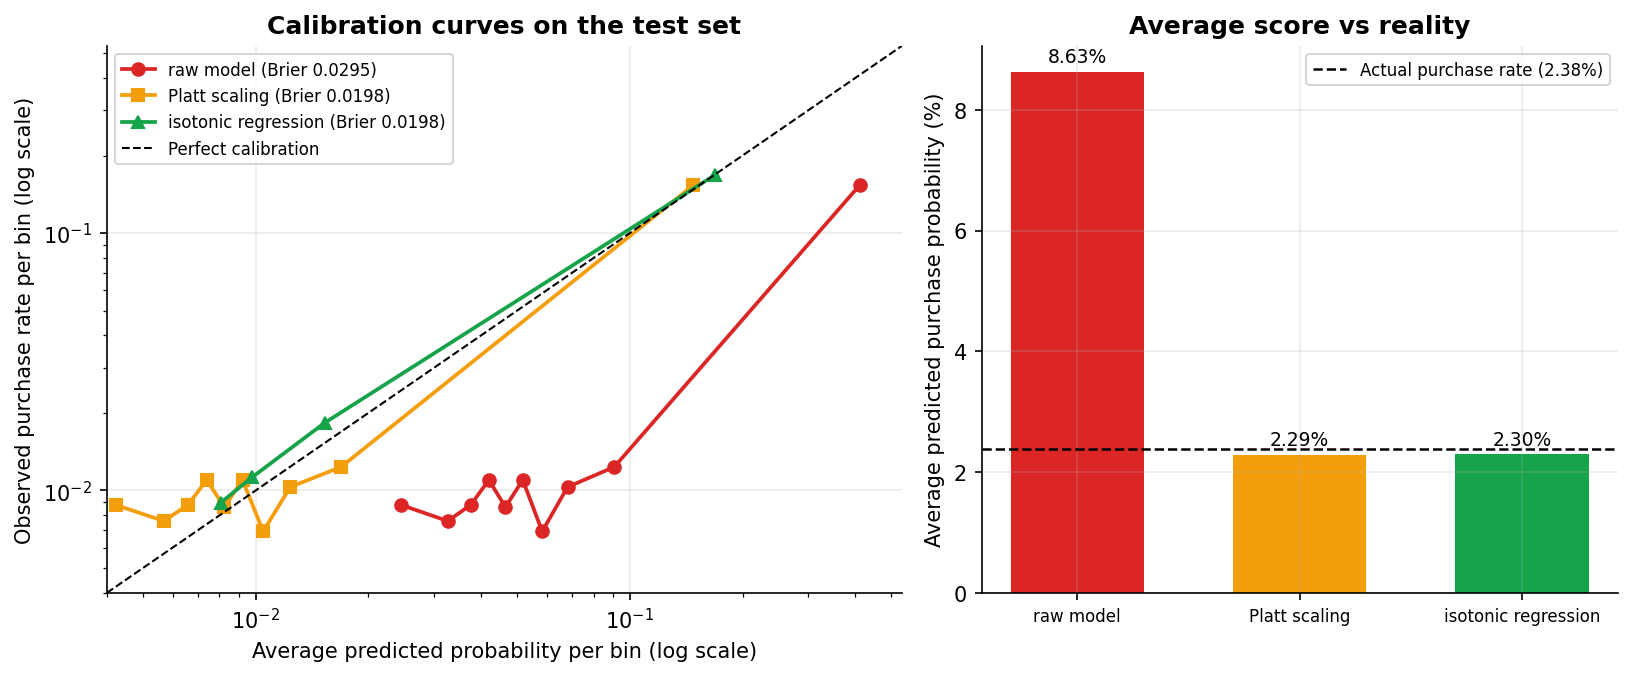

In [31]:
show_csv("calibration_results.csv")
show_img("ppm-10-calibration-curves.png", 950)

## 7.Model explaination
*    Model explanation with SHAP
*    A global view (which features matter across customers) and a local view (why one customer scored high).

Blog parts 5 and 9.

Source file in the repo: `src/07_shap_explainability.py`

In [32]:
"""
07 - Explain the LightGBM model with SHAP.

SHAP answers two different questions:
    Local (one customer)  - why did THIS customer get a high score?
    Global (all customers) - which features matter most, on average?

One detail matters when reading the numbers: for a tree model, SHAP values
are on the model's RAW OUTPUT scale (log-odds), not in probability points.
A positive SHAP value pushes the score up; a negative one pulls it down.
SHAP also describes what the MODEL is doing, not what causes what in the
real world.

Outputs:
    outputs/shap_global_importance.csv, outputs/importance_comparison.csv
    outputs/shap_customer_example.csv
    images/ppm-11-shap-summary-beeswarm.png
    images/ppm-12-shap-global-bar.png
    images/ppm-13-shap-waterfall.png

Run it with:
    python src/07_shap_explainability.py
"""

import joblib
import matplotlib
import numpy as np
import pandas as pd
import shap

import config as cfg
import utils

matplotlib.use("Agg")           # draw charts without needing a display
MODEL_TO_EXPLAIN = "lightgbm"
N_CUSTOMERS_TO_EXPLAIN = 4000    # SHAP is slow on the full test set, so we use a sample


def get_shap_values_for_positive_class(explainer, X):
    """shap.TreeExplainer can return its answer in a few different shapes,
    depending on the model type and shap version. This function always
    returns one plain (n_rows, n_features) array: the pull on the positive
    (purchase) class, and the "starting point" score before any features
    are considered."""
    raw_values = explainer.shap_values(X)
    if isinstance(raw_values, list):                 # older shap: one array per class
        values = raw_values[1]
    else:
        values = raw_values
    if values.ndim == 3:                              # newer shap: (rows, features, classes)
        values = values[:, :, 1]
    base_value = float(np.ravel(explainer.expected_value)[-1])
    return values, base_value


def compare_three_views_of_importance(shap_importance, model, feature_names):
    """Global feature importance can be measured a few different ways.
    We line three of them up side by side so the reader can see whether
    they broadly agree."""
    tree_gain = pd.Series(model.booster_.feature_importance("gain"), index=feature_names)
    tree_gain = (tree_gain / tree_gain.sum()).rename("lgbm_gain_share")

    logistic_model = joblib.load(cfg.MODEL_DIR / "logistic_regression.joblib")
    logistic_coefficient = pd.Series(logistic_model[-1].coef_[0], index=feature_names).rename("logreg_std_coef")

    return shap_importance.set_index("feature").join(tree_gain).join(logistic_coefficient).head(10).round(4)


def plot_beeswarm(shap_values, X, path):
    plt = utils.set_plot_style()
    plt.figure()
    shap.summary_plot(shap_values, X, max_display=12, show=False, plot_size=(8, 5.5))
    plt.title("SHAP summary: each dot is one customer", fontsize=11, fontweight="bold")
    plt.savefig(path)
    plt.close()


def plot_global_bar(importance_table, path):
    plt = utils.set_plot_style()
    top_ten = importance_table.head(10).iloc[::-1]      # reverse so the biggest bar is on top
    fig, ax = plt.subplots(figsize=(6.8, 4.6))
    ax.barh(top_ten["feature"], top_ten["mean_abs_shap"], color=utils.BLUE)
    ax.set(xlabel="Mean |SHAP value| (average pull on the log-odds score)",
           title="Global importance: what moves scores most")
    fig.savefig(path)
    plt.close(fig)


def plot_waterfall_for_one_customer(shap_values, base_value, X, feature_names, row, title, path):
    plt = utils.set_plot_style()
    explanation = shap.Explanation(values=shap_values[row], base_values=base_value,
                                   data=X.iloc[row].to_numpy(), feature_names=feature_names)
    plt.figure()
    shap.plots.waterfall(explanation, max_display=9, show=False)
    plt.gcf().set_size_inches(8, 5)
    plt.title(title, fontsize=10, fontweight="bold")
    plt.savefig(path)
    plt.close()


if __name__ == "__main__":
    data = utils.load_dataset()
    feature_names = joblib.load(cfg.MODEL_DIR / "feature_list.joblib")
    _, _, test = utils.time_split(data)
    sample = test.sample(N_CUSTOMERS_TO_EXPLAIN, random_state=cfg.SEED).reset_index(drop=True)
    X = sample[feature_names]

    model = joblib.load(cfg.MODEL_DIR / f"{MODEL_TO_EXPLAIN}.joblib")
    explainer = shap.TreeExplainer(model)
    shap_values, base_value = get_shap_values_for_positive_class(explainer, X)
    print(f"Base value (average raw output before any feature, log-odds): {base_value:.3f}")

    # --- global importance: which features move the score the most, on average? ----------
    global_importance = pd.DataFrame({"feature": feature_names, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
    global_importance = global_importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    global_importance.round(4).to_csv(cfg.OUT_DIR / "shap_global_importance.csv", index=False)
    print("\nTop 10 features by mean |SHAP|")
    print(global_importance.head(10).round(3).to_string(index=False))

    comparison = compare_three_views_of_importance(global_importance, model, feature_names)
    comparison.to_csv(cfg.OUT_DIR / "importance_comparison.csv")
    print("\nSHAP vs tree gain vs logistic coefficient")
    print(comparison.to_string())

    plot_beeswarm(shap_values, X, cfg.IMG_DIR / "ppm-11-shap-summary-beeswarm.png")
    plot_global_bar(global_importance, cfg.IMG_DIR / "ppm-12-shap-global-bar.png")

    # --- local explanation: why did our highest-scoring sampled customer score high? -------
    raw_scores = model.predict(X, raw_score=True)
    top_row = int(np.argmax(raw_scores))
    customer_id = sample.loc[top_row, "customer_id"]
    plot_waterfall_for_one_customer(shap_values, base_value, X, feature_names, top_row,
                                    f"Why customer {customer_id} scored high (raw log-odds)",
                                    cfg.IMG_DIR / "ppm-13-shap-waterfall.png")

    contribution = pd.DataFrame({"feature": feature_names, "value": X.iloc[top_row].to_numpy(),
                                 "shap": shap_values[top_row]})
    contribution = contribution.reindex(contribution["shap"].abs().sort_values(ascending=False).index).head(8).round(3)
    contribution.to_csv(cfg.OUT_DIR / "shap_customer_example.csv", index=False)

    predicted_probability = 1 / (1 + np.exp(-raw_scores[top_row]))     # uncalibrated, for illustration only
    print(f"\nCustomer {customer_id}: raw log-odds {raw_scores[top_row]:.2f} -> "
          f"probability {predicted_probability:.2f} (uncalibrated)")
    print(contribution.to_string(index=False))

    # A sanity check: base value + all of a customer's SHAP values should equal their raw score.
    biggest_gap = float(np.abs(base_value + shap_values.sum(axis=1) - raw_scores).max())
    print(f"\nAdditivity check (should be close to zero): {biggest_gap:.2e}")


Base value (average raw output before any feature, log-odds): -2.759

Top 10 features by mean |SHAP|
                     feature  mean_abs_shap
days_since_last_product_view          0.209
          events_per_session          0.209
            product_views_7d          0.177
    avg_session_duration_min          0.091
             avg_hour_of_day          0.072
       days_since_last_visit          0.070
    days_since_last_cart_add          0.065
                cart_rate_7d          0.056
    days_since_last_purchase          0.053
             add_to_carts_7d          0.047

SHAP vs tree gain vs logistic coefficient
                              mean_abs_shap  lgbm_gain_share  logreg_std_coef
feature                                                                      
days_since_last_product_view         0.2092           0.1173           0.0148
events_per_session                   0.2086           0.0354           0.4236
product_views_7d                     0.1772           0.3858

**Results**

,feature,mean_abs_shap
0,days_since_last_product_view,0.2092
1,events_per_session,0.2086
2,product_views_7d,0.1772
3,avg_session_duration_min,0.0914
4,avg_hour_of_day,0.0723
5,days_since_last_visit,0.0703
6,days_since_last_cart_add,0.0651
7,cart_rate_7d,0.0555
8,days_since_last_purchase,0.0527
9,add_to_carts_7d,0.0466


,feature,mean_abs_shap,lgbm_gain_share,logreg_std_coef
0,days_since_last_product_view,0.2092,0.1173,0.0148
1,events_per_session,0.2086,0.0354,0.4236
2,product_views_7d,0.1772,0.3858,0.5673
3,avg_session_duration_min,0.0914,0.0351,-0.0476
4,avg_hour_of_day,0.0723,0.0246,0.0432
5,days_since_last_visit,0.0703,0.0305,-0.0788
6,days_since_last_cart_add,0.0651,0.0315,-0.2860
7,cart_rate_7d,0.0555,0.0490,0.1475
8,days_since_last_purchase,0.0527,0.0378,0.3306
9,add_to_carts_7d,0.0466,0.0300,-0.1087


,feature,value,shap
0,product_views_7d,5.000,1.430
1,days_since_last_product_view,0.545,0.729
2,events_per_session,14.000,0.668
3,cart_rate_7d,0.200,0.225
4,avg_session_duration_min,13.517,0.199
5,add_to_carts_7d,1.000,0.172
6,days_since_last_purchase,0.000,0.150
7,days_since_last_visit,0.553,0.133


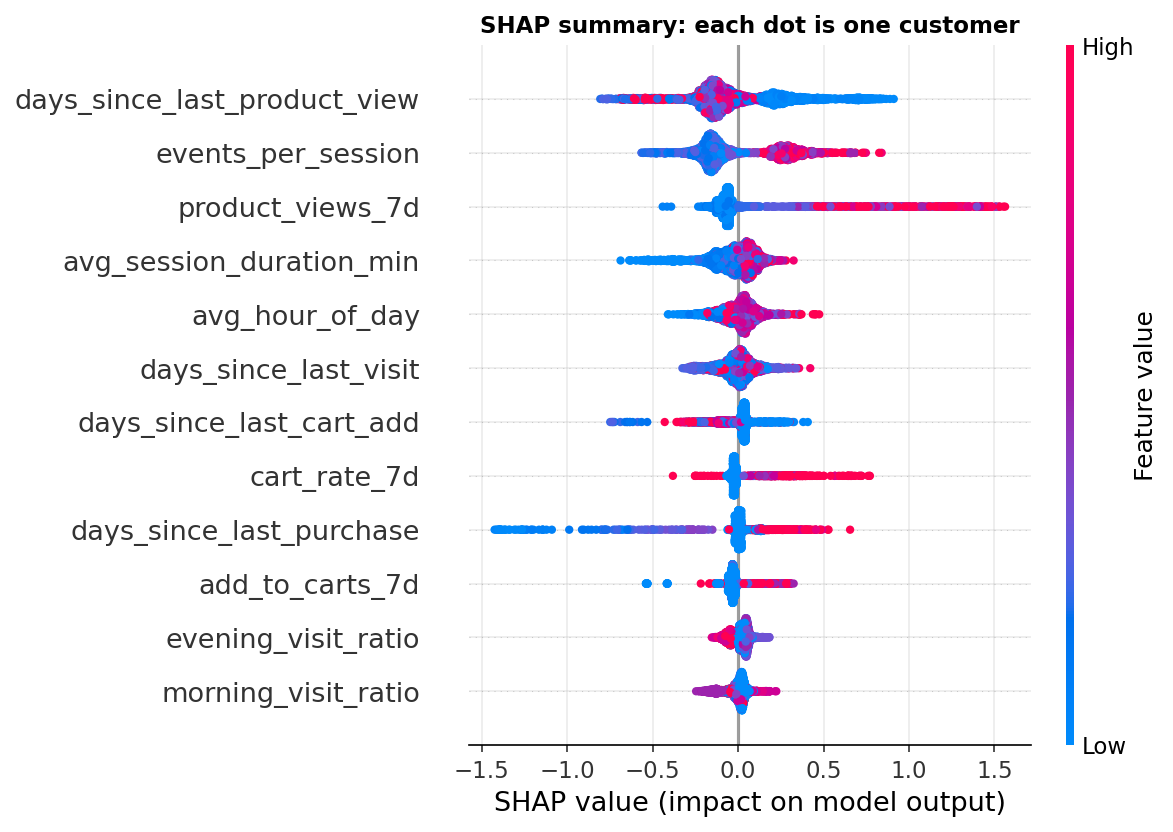

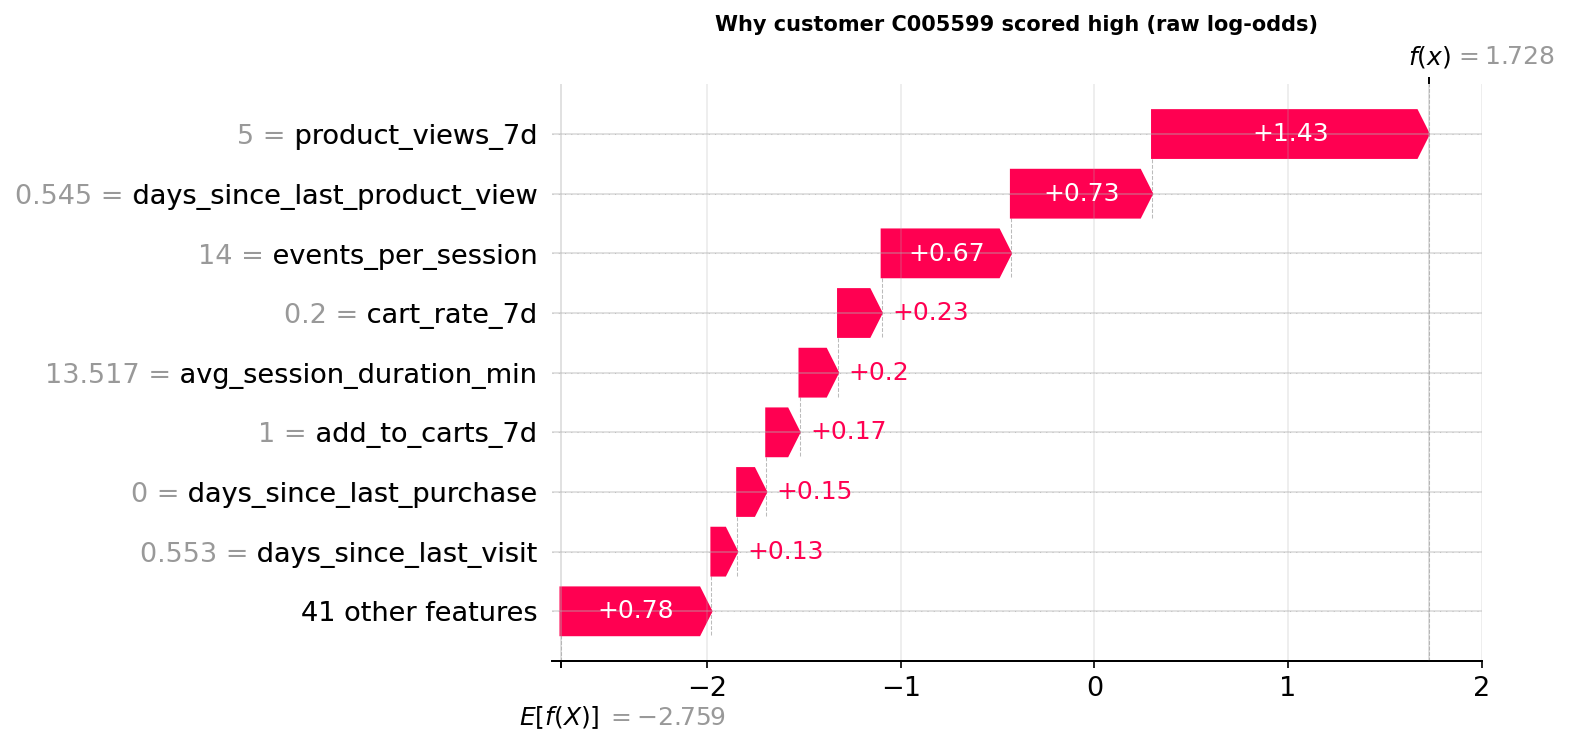

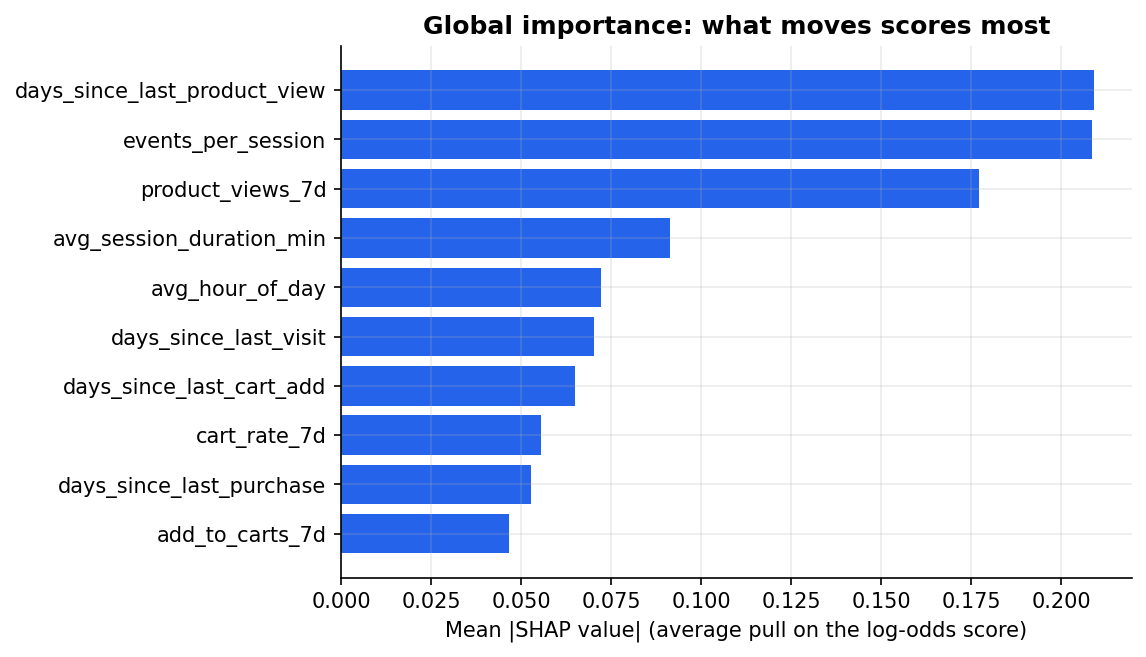

In [33]:
show_csv("shap_global_importance.csv", 10)
show_csv("importance_comparison.csv", 10)
show_csv("shap_customer_example.csv")
show_img("ppm-11-shap-summary-beeswarm.png", 700)
show_img("ppm-13-shap-waterfall.png", 700)
show_img("ppm-12-shap-global-bar.png", 600)

## 8.Propensity versus uplift
* A simulated randomized email campaign shows why ranking by likelihood to buy differs from ranking by the effect of the email.

Blog part 6.

Source file in the repo: `src/08_propensity_vs_uplift.py`

In [34]:
"""
08 - Propensity vs uplift, using a simulated randomised email campaign.

This script uses its OWN small simulation (not the BrightCart clickstream),
because to compare propensity and uplift fairly we need to know the TRUE
effect of the email on each customer -- something we can only know in a
simulation or a real randomised experiment.

Four hidden customer types (the classic "uplift quadrant" from Part 1):
    sure thing    - buys anyway; the email changes nothing
    persuadable   - the email genuinely helps; these are who we want to reach
    lost cause    - unlikely to buy either way; the email changes nothing
    sleeping dog  - the email actually annoys them and LOWERS their chance

We randomly email half of a simulated customer base (treatment) and leave
the other half alone (control). That randomisation is what lets us measure
each targeting strategy's TRUE incremental effect afterwards.

Two ways to choose who to email:
    A. Propensity ranking - "who is likely to buy anyway?"
    B. Uplift ranking     - "who will buy BECAUSE of the email?"
       (the classic two-model approach: train one model on people who got
       the email, one on people who did not, and take the difference)

Outputs:
    outputs/uplift_results.csv, outputs/uplift_segments.csv
    images/ppm-16-uplift-vs-propensity-curve.png

Run it with:
    python src/08_propensity_vs_uplift.py
"""

import lightgbm as lgb
import numpy as np
import pandas as pd

import config as cfg
import utils

N_CUSTOMERS = 60_000
FEATURE_NAMES = ["intent_signal", "price_sensitivity", "email_fatigue", "recency"]

# The four hidden segments: how common each is, their base purchase chance
# with NO email, and how much the email changes that chance (its "effect").
SEGMENTS = {
    "sure_thing":   {"share": 0.15, "base_rate": 0.55, "email_effect": 0.00},
    "persuadable":  {"share": 0.25, "base_rate": 0.12, "email_effect": 0.16},
    "lost_cause":   {"share": 0.50, "base_rate": 0.02, "email_effect": 0.00},
    "sleeping_dog": {"share": 0.10, "base_rate": 0.10, "email_effect": -0.07},
}


def simulate_customers(rng: np.random.Generator) -> pd.DataFrame:
    """
    Create N_CUSTOMERS pretend customers. Each one secretly belongs to one
    of the four segments above, but we only give the model OBSERVABLE
    features that partly (not perfectly) hint at the segment -- exactly
    like a real business, where the true segment is never directly known.
    """
    segment_names = list(SEGMENTS)
    segment_shares = [SEGMENTS[s]["share"] for s in segment_names]
    segment = rng.choice(segment_names, N_CUSTOMERS, p=segment_shares)

    base_rate = np.array([SEGMENTS[s]["base_rate"] for s in segment])
    email_effect = np.array([SEGMENTS[s]["email_effect"] for s in segment])

    # Observable features: each one leans toward a particular segment, but
    # with enough noise that no single feature reveals the segment on its own.
    intent_signal = np.where(segment == "sure_thing", rng.normal(2.0, 0.8, N_CUSTOMERS),
                     np.where(segment == "persuadable", rng.normal(0.6, 0.8, N_CUSTOMERS),
                     np.where(segment == "lost_cause", rng.normal(-1.0, 0.8, N_CUSTOMERS),
                              rng.normal(0.0, 0.8, N_CUSTOMERS))))
    price_sensitivity = np.where(segment == "persuadable", rng.normal(1.2, 0.7, N_CUSTOMERS),
                                  rng.normal(0.0, 0.9, N_CUSTOMERS))
    email_fatigue = np.where(segment == "sleeping_dog", rng.normal(1.6, 0.7, N_CUSTOMERS),
                             rng.normal(0.0, 0.9, N_CUSTOMERS))
    recency = rng.normal(0, 1, N_CUSTOMERS)

    return pd.DataFrame({
        "segment": segment, "intent_signal": intent_signal, "price_sensitivity": price_sensitivity,
        "email_fatigue": email_fatigue, "recency": recency,
        "true_base_rate": base_rate, "true_email_effect": email_effect,
    })


def run_randomised_campaign(customers: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    """Randomly email half the customers, then simulate whether each one
    purchases, using their true (hidden) base rate and email effect."""
    customers = customers.copy()
    customers["treated"] = rng.random(len(customers)) < 0.5
    purchase_chance = customers["true_base_rate"] + customers["treated"] * customers["true_email_effect"]
    purchase_chance = purchase_chance.clip(0.001, 0.999)
    customers["purchased"] = (rng.random(len(customers)) < purchase_chance).astype(int)
    return customers


def train_control_and_treatment_models(train_customers: pd.DataFrame):
    """The classic two-model ("T-learner") approach to uplift:
       one model learns from customers who did NOT get the email,
       one model learns from customers who DID get the email."""
    settings = dict(n_estimators=150, learning_rate=0.05, num_leaves=8, min_child_samples=100,
                    subsample=0.8, subsample_freq=1, random_state=cfg.SEED, verbose=-1, n_jobs=-1)
    not_emailed = train_customers[train_customers["treated"] == 0]
    was_emailed = train_customers[train_customers["treated"] == 1]
    control_model = lgb.LGBMClassifier(**settings).fit(not_emailed[FEATURE_NAMES], not_emailed["purchased"])
    treatment_model = lgb.LGBMClassifier(**settings).fit(was_emailed[FEATURE_NAMES], was_emailed["purchased"])
    return control_model, treatment_model


def score_customers(control_model, treatment_model, customers: pd.DataFrame):
    """propensity  = chance of buying with NO email (what most models predict)
       uplift      = chance WITH email minus chance WITHOUT it (the true target for uplift)"""
    propensity = control_model.predict_proba(customers[FEATURE_NAMES])[:, 1]
    chance_if_emailed = treatment_model.predict_proba(customers[FEATURE_NAMES])[:, 1]
    uplift = chance_if_emailed - propensity
    return propensity, uplift


def incremental_buyers_if_we_contact_top_k(purchased, treated, score, fractions):
    """
    For each contact fraction (say, top 10%, top 20%, ...): if we had
    emailed only that top slice, how many MORE purchases would we see
    compared to not emailing them? We estimate this using the customers
    already in that slice: (their purchase rate when emailed) minus
    (their purchase rate when not emailed), times how many are in the slice.
    """
    order = np.argsort(-score)
    purchased, treated = purchased[order], treated[order]
    incremental_buyers = []
    for fraction in fractions:
        k = int(len(purchased) * fraction)
        in_slice_purchased, in_slice_treated = purchased[:k], treated[:k]
        rate_if_emailed = in_slice_purchased[in_slice_treated == 1].mean() if (in_slice_treated == 1).any() else 0
        rate_if_not_emailed = in_slice_purchased[in_slice_treated == 0].mean() if (in_slice_treated == 0).any() else 0
        incremental_buyers.append((rate_if_emailed - rate_if_not_emailed) * k)
    return np.array(incremental_buyers)


def plot_incremental_buyers(fractions, by_uplift, by_propensity, by_random, path):
    plt = utils.set_plot_style()
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(fractions * 100, by_uplift, color=utils.GREEN, lw=2.4, label="Ranked by uplift")
    ax.plot(fractions * 100, by_propensity, color=utils.BLUE, lw=2.4, label="Ranked by propensity")
    ax.plot(fractions * 100, by_random, color=utils.GREY, lw=1.6, ls="--", label="Random order")
    ax.axhline(0, color="black", lw=0.8)
    ax.set(xlabel="% of customers emailed (best-ranked first)", ylabel="Incremental buyers caused by the email",
           title="Propensity finds buyers. Uplift finds buyers the email created.")
    ax.legend()
    fig.savefig(path)


if __name__ == "__main__":
    rng = np.random.default_rng(cfg.SEED)

    customers = simulate_customers(rng)
    customers = run_randomised_campaign(customers, rng)

    shuffled_index = rng.permutation(N_CUSTOMERS)
    train_customers = customers.iloc[shuffled_index[: N_CUSTOMERS // 2]]
    holdout_customers = customers.iloc[shuffled_index[N_CUSTOMERS // 2:]]

    control_model, treatment_model = train_control_and_treatment_models(train_customers)
    propensity, uplift = score_customers(control_model, treatment_model, holdout_customers)
    purchased = holdout_customers["purchased"].to_numpy()
    treated = holdout_customers["treated"].to_numpy()

    fractions = np.linspace(0.02, 1.0, 50)
    incremental_by_uplift = incremental_buyers_if_we_contact_top_k(purchased, treated, uplift, fractions)
    incremental_by_propensity = incremental_buyers_if_we_contact_top_k(purchased, treated, propensity, fractions)
    incremental_by_random = incremental_buyers_if_we_contact_top_k(
        purchased, treated, np.random.default_rng(1).random(len(purchased)), fractions)

    # --- the headline comparison: email the top 30% only --------------------------------
    target_fraction = 0.30
    idx = int(np.argmin(np.abs(fractions - target_fraction)))
    n_holdout = len(holdout_customers)
    results = pd.DataFrame({
        "strategy": ["Random 30%", "Highest propensity 30%", "Highest uplift 30%", "Email everyone (100%)"],
        "customers_emailed": [int(n_holdout * target_fraction)] * 3 + [n_holdout],
        "incremental_buyers": [incremental_by_random[idx], incremental_by_propensity[idx],
                               incremental_by_uplift[idx], incremental_by_propensity[-1]],
    })
    results["incremental_buyers"] = results["incremental_buyers"].round(0)
    results["incremental_per_1000_emails"] = (1000 * results["incremental_buyers"] / results["customers_emailed"]).round(1)
    results.to_csv(cfg.OUT_DIR / "uplift_results.csv", index=False)
    print(results.to_string(index=False))

    # --- what each hidden segment actually looked like, measured from the randomised data --
    segment_summary = holdout_customers.groupby("segment").apply(lambda g: pd.Series({
        "share": len(g) / n_holdout,
        "rate_no_email": g.loc[g.treated == 0, "purchased"].mean(),
        "rate_with_email": g.loc[g.treated == 1, "purchased"].mean(),
    }), include_groups=False)
    segment_summary["measured_uplift"] = segment_summary["rate_with_email"] - segment_summary["rate_no_email"]
    segment_summary.round(4).to_csv(cfg.OUT_DIR / "uplift_segments.csv")
    print("\nSegment view (measured from the randomised holdout)")
    print(segment_summary.round(3).to_string())

    plot_incremental_buyers(fractions, incremental_by_uplift, incremental_by_propensity, incremental_by_random,
                            cfg.IMG_DIR / "ppm-16-uplift-vs-propensity-curve.png")


              strategy  customers_emailed  incremental_buyers  incremental_per_1000_emails
            Random 30%               9000               245.0                         27.2
Highest propensity 30%               9000               502.0                         55.8
    Highest uplift 30%               9000               887.0                         98.6
 Email everyone (100%)              30000               904.0                         30.1

Segment view (measured from the randomised holdout)
              share  rate_no_email  rate_with_email  measured_uplift
segment                                                             
lost_cause    0.503          0.023            0.016           -0.007
persuadable   0.250          0.120            0.285            0.165
sleeping_dog  0.099          0.102            0.033           -0.068
sure_thing    0.148          0.548            0.541           -0.006


**Results**

,strategy,customers_emailed,incremental_buyers,incremental_per_1000_emails
0,Random 30%,9000,245.0,27.2
1,Highest propensity 30%,9000,502.0,55.8
2,Highest uplift 30%,9000,887.0,98.6
3,Email everyone (100%),30000,904.0,30.1


,segment,share,rate_no_email,rate_with_email,measured_uplift
0,lost_cause,0.5028,0.0230,0.0157,-0.0073
1,persuadable,0.2499,0.1197,0.2848,0.1651
2,sleeping_dog,0.0990,0.1015,0.0333,-0.0682
3,sure_thing,0.1483,0.5475,0.5414,-0.0061


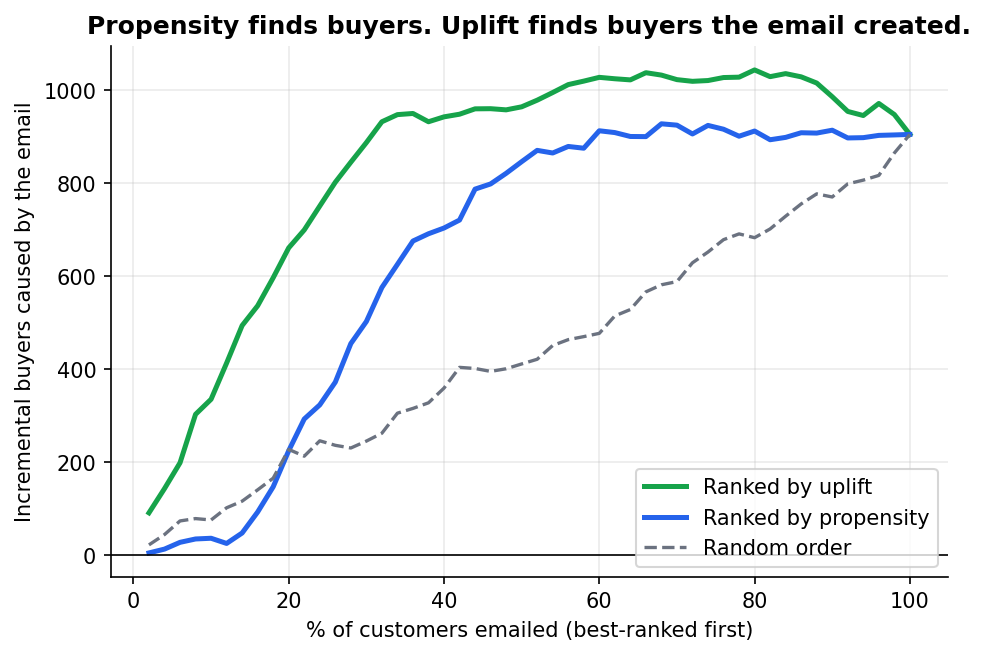

In [35]:
show_csv("uplift_results.csv")
show_csv("uplift_segments.csv")
show_img("ppm-16-uplift-vs-propensity-curve.png", 700)

## 9.Model drift
* Population Stability Index on the inputs, the share of customers above a fixed cut-off, and weekly performance.
* A simulated site redesign shows what drift looks like.

Blog part 6.

Source file in the repo: `src/09_drift_monitoring.py`

In [36]:
"""
09 - Model monitoring: has the input data drifted, and is the model still working?

A model that looked great in testing can quietly go stale in production if
customer behaviour changes. We check for that in three ways:

    1. Feature drift  - has the SHAPE of an input feature changed?
                        Measured with the Population Stability Index (PSI).
    2. Score drift    - has the SHARE of customers above our usual cut-off
                        changed, even if nothing else looks wrong?
    3. Performance    - week by week, is the model still finding buyers?

To make drift concrete, we simulate a pretend website redesign (more
product views per visit, more mobile traffic) and show what it would do
to the model's inputs and scores, next to what real weeks actually look
like.

PSI rule of thumb:
    below 0.10   -> stable
    0.10 to 0.25 -> worth investigating
    above 0.25   -> a real shift

Outputs:
    outputs/weekly_monitoring.csv, outputs/psi_redesign.csv
    images/ppm-17-drift-psi-and-score.png

Run it with:
    python src/09_drift_monitoring.py
"""

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

import config as cfg
import utils

MODEL_NAME = "lightgbm"


def population_stability_index(reference_values, current_values, n_bins: int = 10) -> float:
    """
    PSI compares two distributions of the same feature: a REFERENCE period
    (usually training data) and a CURRENT period. It works like this:
      1. Cut the reference values into n_bins equal-size groups.
      2. See what share of the reference data falls in each group, and
         what share of the current data falls in the SAME groups.
      3. If a group's share changed a lot between the two periods, that
         adds a lot to the PSI score.
    """
    bin_edges = np.unique(np.quantile(reference_values, np.linspace(0, 1, n_bins + 1)))
    if len(bin_edges) < 3:            # a feature with almost no variation -- nothing to compare
        return 0.0
    bin_edges[0], bin_edges[-1] = -np.inf, np.inf

    reference_share = np.histogram(reference_values, bin_edges)[0] / len(reference_values)
    current_share = np.histogram(current_values, bin_edges)[0] / len(current_values)
    reference_share = np.clip(reference_share, 1e-4, None)     # avoid dividing by zero below
    current_share = np.clip(current_share, 1e-4, None)

    return float(np.sum((current_share - reference_share) * np.log(current_share / reference_share)))


def simulate_a_website_redesign(features: pd.DataFrame) -> pd.DataFrame:
    """Pretend the site changed to an infinite-scroll layout: customers see
    far more products per visit, and more of them arrive on mobile."""
    redesigned = features.copy()
    for column in ["product_views_7d", "product_views_30d", "unique_products_viewed"]:
        redesigned[column] = np.ceil(redesigned[column] * 1.8)     # ceil so small counts move too
    redesigned["events_per_session"] *= 1.3
    mobile_shift = 0.25
    redesigned["mobile_ratio"] = (redesigned["mobile_ratio"] + mobile_shift).clip(upper=1)
    redesigned["desktop_ratio"] = (redesigned["desktop_ratio"] - mobile_shift).clip(lower=0)
    return redesigned


def score_with_model(model, calibrator, features: pd.DataFrame) -> np.ndarray:
    raw_score = model.predict_proba(features)[:, 1]
    return calibrator.predict(raw_score)


def plot_drift_charts(top_psi_features, weekly_results, path):
    plt = utils.set_plot_style()
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), gridspec_kw={"width_ratios": [1, 1.1]})

    # left: which features moved the most after the simulated redesign?
    ax = axes[0]
    bars = top_psi_features.iloc[::-1]
    y_positions = np.arange(len(bars))
    ax.barh(y_positions + 0.2, bars["psi_after_redesign"], height=0.38, color=utils.RED, label="After simulated redesign")
    ax.barh(y_positions - 0.2, bars["psi_normal_week"], height=0.38, color=utils.BLUE, label="Normal week")
    ax.axvline(0.10, color=utils.ORANGE, ls="--", lw=1.2)
    ax.axvline(0.25, color=utils.RED, ls="--", lw=1.2)
    ax.text(0.105, len(bars) - 0.35, "0.10", color=utils.ORANGE, fontsize=8)
    ax.text(0.255, len(bars) - 0.35, "0.25", color=utils.RED, fontsize=8)
    ax.set_yticks(y_positions, bars.index, fontsize=8)
    ax.set(xlabel="Population Stability Index (PSI)", title="Feature drift: which inputs moved?")
    ax.legend(fontsize=8, loc="lower right")

    # right: week by week, what share of customers sit above our usual cut-off?
    ax = axes[1]
    dates = pd.to_datetime(weekly_results["snapshot_date"])
    ax.plot(dates, weekly_results["share_above_cutoff"] * 100, color=utils.GREEN, lw=2, marker="s", ms=4,
            label="Real weeks")
    ax.plot(dates, weekly_results["share_above_cutoff_if_redesigned"] * 100, color=utils.RED, lw=2, ls="--",
            marker="^", ms=4, label="If a redesign shifted the inputs")
    ax.axhline(cfg.TOP_FRACTION * 100, color="black", lw=1, ls=":", label="Expected share (10%)")
    ax.set(ylabel="% of customers above the training-time top-10% cut-off",
           title="Prediction drift: audience size at a fixed cut-off", ylim=(0, None))
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(path)


if __name__ == "__main__":
    data = utils.load_dataset()
    feature_names = joblib.load(cfg.MODEL_DIR / "feature_list.joblib")
    model = joblib.load(cfg.MODEL_DIR / f"{MODEL_NAME}.joblib")
    calibrator = joblib.load(cfg.MODEL_DIR / "isotonic.joblib")
    train, val, test = utils.time_split(data)
    reference_features = train[feature_names]

    # The score cut-off that defined "top 10%" back when we validated the model.
    validation_scores = score_with_model(model, calibrator, val[feature_names])
    cutoff = float(np.quantile(validation_scores, 1 - cfg.TOP_FRACTION))

    # --- week by week performance and drift, for every week after training --------------
    weekly_rows = []
    for snapshot_date, week_data in data[data["snapshot_date"] >= cfg.VAL_START].groupby("snapshot_date"):
        real_scores = score_with_model(model, calibrator, week_data[feature_names])
        redesigned_features = simulate_a_website_redesign(week_data[feature_names])
        redesigned_scores = score_with_model(model, calibrator, redesigned_features)
        actual_outcome = week_data[cfg.TARGET].to_numpy()

        feature_psi_values = [population_stability_index(reference_features[f], week_data[f]) for f in feature_names]
        weekly_rows.append({
            "snapshot_date": snapshot_date.date(), "customers": len(week_data), "observed_rate": actual_outcome.mean(),
            "mean_score": real_scores.mean(), "roc_auc": roc_auc_score(actual_outcome, real_scores),
            "pr_auc": average_precision_score(actual_outcome, real_scores),
            "lift_top10": utils.lift_at(actual_outcome, real_scores, 0.10),
            "max_feature_psi": max(feature_psi_values),
            "share_above_cutoff": float((real_scores >= cutoff).mean()),
            "share_above_cutoff_if_redesigned": float((redesigned_scores >= cutoff).mean()),
        })
    weekly_results = pd.DataFrame(weekly_rows).round(4)
    weekly_results.to_csv(cfg.OUT_DIR / "weekly_monitoring.csv", index=False)
    print(weekly_results.to_string(index=False))

    # A feature that drifts by construction, kept OUT of the model on purpose (see config.py).
    excluded_feature = cfg.EXCLUDE_FEATURES[0]
    latest_week = data[data["snapshot_date"] == data["snapshot_date"].max()]
    drift_of_excluded_feature = population_stability_index(train[excluded_feature], latest_week[excluded_feature])
    print(f"\nExcluded feature '{excluded_feature}': PSI train vs last week = {drift_of_excluded_feature:.2f} "
          f"(drifts by construction, so it is not given to the model)")

    # --- PSI for every feature: a normal week vs the simulated redesign ------------------
    last_week_features = test[test["snapshot_date"] == test["snapshot_date"].max()][feature_names]
    redesigned_last_week = simulate_a_website_redesign(last_week_features)
    psi_normal_week = pd.Series({f: population_stability_index(reference_features[f], last_week_features[f])
                                 for f in feature_names})
    psi_after_redesign = pd.Series({f: population_stability_index(reference_features[f], redesigned_last_week[f])
                                    for f in feature_names})
    psi_table = pd.DataFrame({"psi_normal_week": psi_normal_week, "psi_after_redesign": psi_after_redesign})
    psi_table = psi_table.sort_values("psi_after_redesign", ascending=False)
    psi_table.round(3).to_csv(cfg.OUT_DIR / "psi_redesign.csv")
    print("\nTop PSI features after the simulated redesign")
    print(psi_table.head(8).round(3).to_string())

    plot_drift_charts(psi_table.head(8), weekly_results, cfg.IMG_DIR / "ppm-17-drift-psi-and-score.png")


snapshot_date  customers  observed_rate  mean_score  roc_auc  pr_auc  lift_top10  max_feature_psi  share_above_cutoff  share_above_cutoff_if_redesigned
   2025-05-05       7450         0.0203      0.0208   0.7973  0.2383      6.2914           0.0021              0.0913                            0.1436
   2025-05-12       7371         0.0243      0.0236   0.8054  0.2091      6.7048           0.0024              0.1053                            0.1528
   2025-05-19       7340         0.0248      0.0229   0.8008  0.1976      6.3187           0.0016              0.1064                            0.1544
   2025-05-26       7375         0.0217      0.0237   0.8454  0.2532      7.2549           0.0022              0.1051                            0.1572
   2025-06-02       7372         0.0232      0.0231   0.7633  0.1791      5.9080           0.0022              0.1084                            0.1617
   2025-06-09       7402         0.0232      0.0215   0.7842  0.2337      6.4552        

**Results**

,snapshot_date,customers,observed_rate,mean_score,roc_auc,pr_auc,lift_top10,max_feature_psi,share_above_cutoff,share_above_cutoff_if_redesigned
0,2025-05-05,7450,0.0203,0.0208,0.7973,0.2383,6.2914,0.0021,0.0913,0.1436
1,2025-05-12,7371,0.0243,0.0236,0.8054,0.2091,6.7048,0.0024,0.1053,0.1528
2,2025-05-19,7340,0.0248,0.0229,0.8008,0.1976,6.3187,0.0016,0.1064,0.1544
3,2025-05-26,7375,0.0217,0.0237,0.8454,0.2532,7.2549,0.0022,0.1051,0.1572
4,2025-06-02,7372,0.0232,0.0231,0.7633,0.1791,5.9080,0.0022,0.1084,0.1617
5,2025-06-09,7402,0.0232,0.0215,0.7842,0.2337,6.4552,0.0016,0.0970,0.1509
6,2025-06-16,7409,0.0252,0.0231,0.7919,0.2177,6.2643,0.0024,0.1030,0.1560
7,2025-06-23,7412,0.0242,0.0235,0.8129,0.2575,6.8734,0.0016,0.0996,0.1533
8,2025-06-30,7400,0.0250,0.0238,0.8363,0.2081,6.8649,0.0019,0.0995,0.1547
9,2025-07-07,7405,0.0239,0.0225,0.8208,0.2121,6.6146,0.0014,0.1007,0.1526


,Unnamed: 0,psi_normal_week,psi_after_redesign
0,unique_products_viewed,0.000,3.901
1,product_views_30d,0.001,1.952
2,product_views_7d,0.000,0.736
3,events_per_session,0.001,0.647
4,desktop_ratio,0.000,0.423
5,mobile_ratio,0.000,0.350
6,days_since_last_visit,0.002,0.002
7,days_since_last_product_view,0.002,0.002


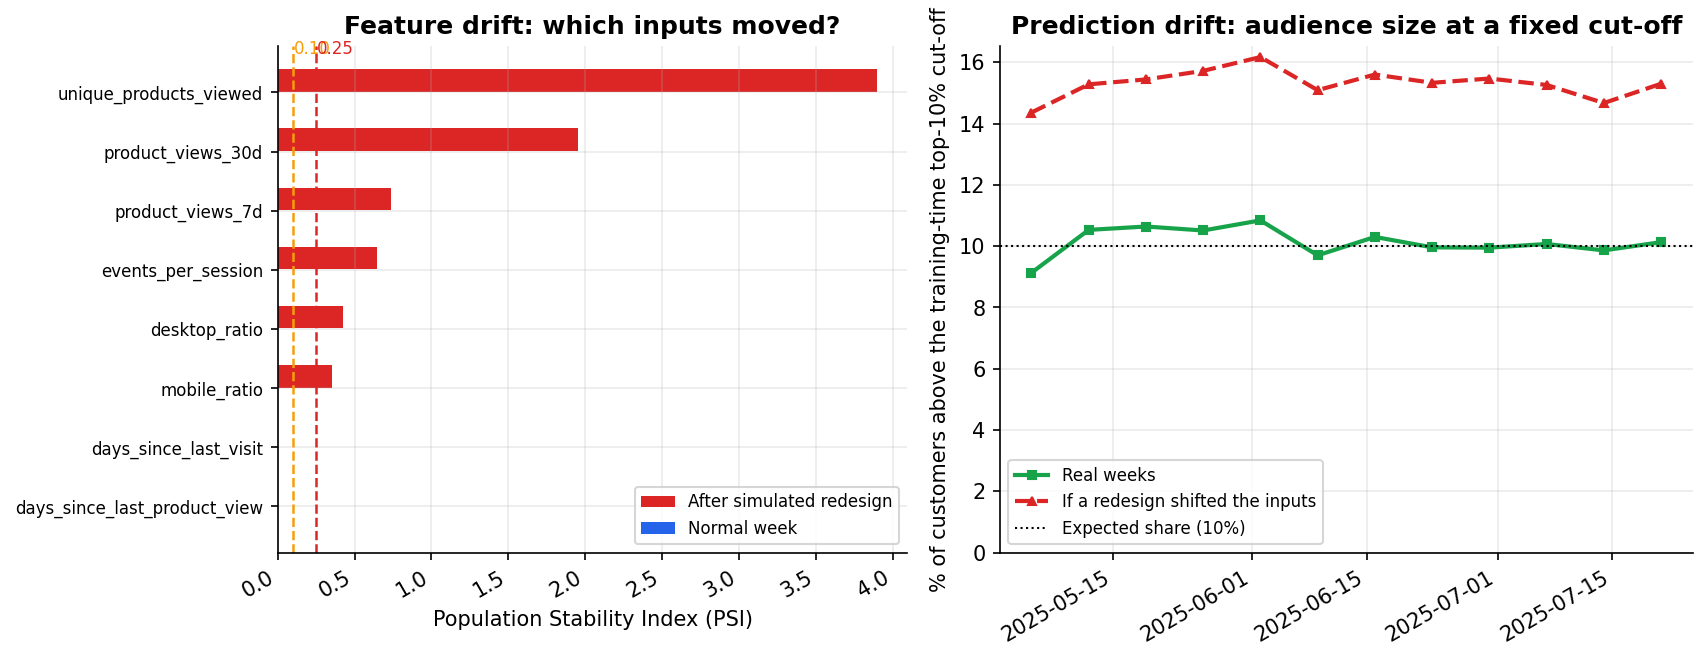

In [37]:
show_csv("weekly_monitoring.csv")
show_csv("psi_redesign.csv", 8)
show_img("ppm-17-drift-psi-and-score.png", 950)

## 10.Audience Building - Turn scores into a campaign audience
* The model says who is likely to buy.
* Business rules decide who may be contacted, and a random holdout keeps the campaign measurable.

Blog parts 5 and 6.

Source file in the repo: `src/10_score_and_select_audience.py`

In [38]:
"""
10 - Turn calibrated scores into an actual campaign audience.

The model answers "who is likely to buy?" Business rules answer "who may
we actually contact?" Those are different questions, and this script keeps
them separate on purpose:

    1. Score every customer active in the last 30 days.
    2. Keep only customers worth contacting on economic grounds: a
       "break-even" rule that only targets a customer if their expected
       revenue (probability times margin) covers the cost of contacting them.
    3. Apply real-world eligibility rules: marketing consent, and not
       contacted too recently.
    4. Hold back a small random slice of the eligible audience as a
       control group, so the campaign's real impact can be measured later.

Outputs:
    outputs/audience_funnel.csv     - how many customers survive each rule
    outputs/campaign_audience.csv   - the final list, with a treatment/holdout flag

Run it with:
    python src/10_score_and_select_audience.py
"""

import joblib
import numpy as np
import pandas as pd

import config as cfg
import utils

MODEL_NAME = "lightgbm"
SCORE_DATE = cfg.LAST_SNAPSHOT
MIN_DAYS_SINCE_LAST_CONTACT = 3
HOLDOUT_SHARE = 0.10

# Simple illustrative campaign economics: only contact a customer if their
# expected profit covers the cost of reaching them.
COST_PER_CONTACT = 1.00
MARGIN_PER_ORDER = 25.00
BREAK_EVEN_PROPENSITY = COST_PER_CONTACT / MARGIN_PER_ORDER


def score_active_customers(data, feature_names, model, calibrator, customers) -> pd.DataFrame:
    """Score everyone active on SCORE_DATE, and attach the business facts
    we need for the eligibility rules below (consent, last contact date)."""
    today = data[data["snapshot_date"] == SCORE_DATE].copy()
    raw_score = model.predict_proba(today[feature_names])[:, 1]
    today["propensity"] = calibrator.predict(raw_score)

    today = today.merge(customers[["customer_id", "marketing_consent", "last_contact_date"]],
                        on="customer_id", how="left")
    today["days_since_last_contact"] = (SCORE_DATE - today["last_contact_date"]).dt.days
    return today


def apply_business_rules(scored_customers: pd.DataFrame, cutoff: float, rng: np.random.Generator):
    """Filter step by step, recording how many customers survive each
    filter -- this table is what makes an eligibility funnel easy to explain."""
    funnel_steps = [("Active customers scored", scored_customers)]

    worth_contacting = scored_customers[scored_customers["propensity"] >= cutoff]
    funnel_steps.append((f"Propensity >= {cutoff:.2f} (break-even rule)", worth_contacting))

    consented = worth_contacting[worth_contacting["marketing_consent"] == 1]
    funnel_steps.append(("... with marketing consent", consented))

    not_recently_contacted = consented[consented["days_since_last_contact"] >= MIN_DAYS_SINCE_LAST_CONTACT]
    funnel_steps.append((f"... not contacted in last {MIN_DAYS_SINCE_LAST_CONTACT} days", not_recently_contacted))

    eligible = not_recently_contacted.copy()
    is_holdout = rng.random(len(eligible)) < HOLDOUT_SHARE
    eligible["group"] = np.where(is_holdout, "holdout_control", "treatment")
    funnel_steps.append(("Final audience (treatment only)", eligible[eligible["group"] == "treatment"]))

    return eligible, funnel_steps


def print_threshold_comparison(scored_customers: pd.DataFrame, cutoff: float):
    """Show what a few different targeting rules would each select, so the
    business can see why a fixed threshold like 0.70 makes no sense here."""
    print(f"Scored customers (active in last 30 days): {len(scored_customers):,}")
    print(f"Average calibrated propensity            : {scored_customers['propensity'].mean():.3f}")
    print(f"Highest calibrated propensity            : {scored_customers['propensity'].max():.3f}")
    print(f"Top-10% cut-off from validation          : {cutoff:.3f}")
    print(f"Break-even propensity (cost/margin)      : {BREAK_EVEN_PROPENSITY:.3f}")
    print("\nHow many customers each selection rule picks:")
    rules = [("Fixed threshold 0.70", scored_customers["propensity"] >= 0.70),
             ("Fixed threshold 0.30", scored_customers["propensity"] >= 0.30),
             ("Fixed threshold 0.10", scored_customers["propensity"] >= 0.10),
             (f"Break-even {BREAK_EVEN_PROPENSITY:.2f}", scored_customers["propensity"] >= BREAK_EVEN_PROPENSITY),
             (f"Top-10% cut-off {cutoff:.3f}", scored_customers["propensity"] >= cutoff)]
    for name, matches in rules:
        expected_buyers = scored_customers.loc[matches, "propensity"].sum()
        print(f"  {name:<28s}{int(matches.sum()):>6,} customers | expected buyers {expected_buyers:>6.0f}")


if __name__ == "__main__":
    rng = np.random.default_rng(cfg.SEED)
    data = utils.load_dataset()
    feature_names = joblib.load(cfg.MODEL_DIR / "feature_list.joblib")
    model = joblib.load(cfg.MODEL_DIR / f"{MODEL_NAME}.joblib")
    calibrator = joblib.load(cfg.MODEL_DIR / "isotonic.joblib")
    customers = pd.read_csv(cfg.DATA_DIR / "customers.csv", parse_dates=["last_contact_date"])

    scored_customers = score_active_customers(data, feature_names, model, calibrator, customers)

    # The cut-off comes from VALIDATION data, not from today's scores, so it does not
    # quietly change every time we run the campaign.
    validation = pd.read_parquet(cfg.OUT_DIR / "predictions_val.parquet")
    calibrated_validation_scores = calibrator.predict(validation[f"p_{MODEL_NAME}"])
    top_10_percent_cutoff = float(np.quantile(calibrated_validation_scores, 1 - cfg.TOP_FRACTION))

    print_threshold_comparison(scored_customers, top_10_percent_cutoff)

    eligible, funnel_steps = apply_business_rules(scored_customers, BREAK_EVEN_PROPENSITY, rng)

    funnel_table = pd.DataFrame({
        "step": [name for name, _ in funnel_steps],
        "customers": [len(rows) for _, rows in funnel_steps],
        "expected_buyers": [rows["propensity"].sum() for _, rows in funnel_steps],
    })
    funnel_table["expected_buyers"] = funnel_table["expected_buyers"].round(0).astype(int)
    funnel_table.to_csv(cfg.OUT_DIR / "audience_funnel.csv", index=False)
    print("\n" + funnel_table.to_string(index=False))

    final_list = eligible[["customer_id", "propensity", "group"]].sort_values("propensity", ascending=False)
    final_list.to_csv(cfg.OUT_DIR / "campaign_audience.csv", index=False)
    n_treatment = (final_list["group"] == "treatment").sum()
    n_holdout = (final_list["group"] == "holdout_control").sum()
    print(f"\nSaved {len(final_list):,} eligible customers ({n_treatment:,} treatment, {n_holdout:,} held out as control).")


Scored customers (active in last 30 days): 7,371
Average calibrated propensity            : 0.024
Highest calibrated propensity            : 0.364
Top-10% cut-off from validation          : 0.015
Break-even propensity (cost/margin)      : 0.040

How many customers each selection rule picks:
  Fixed threshold 0.70             0 customers | expected buyers      0
  Fixed threshold 0.30           195 customers | expected buyers     67
  Fixed threshold 0.10           422 customers | expected buyers    113
  Break-even 0.04                546 customers | expected buyers    119
  Top-10% cut-off 0.015          747 customers | expected buyers    123

                                step  customers  expected_buyers
             Active customers scored       7371              179
Propensity >= 0.04 (break-even rule)        546              119
          ... with marketing consent        464              100
    ... not contacted in last 3 days        419               91
     Final audience (t

**Results**

In [39]:
show_csv("audience_funnel.csv")
show_csv("campaign_audience.csv", 8)

,step,customers,expected_buyers
0,Active customers scored,7371,179
1,Propensity >= 0.04 (break-even rule),546,119
2,... with marketing consent,464,100
3,... not contacted in last 3 days,419,91
4,Final audience (treatment only),383,83


,customer_id,propensity,group
0,C000595,0.363636,treatment
1,C006774,0.363636,holdout_control
2,C005599,0.363636,treatment
3,C004299,0.363636,treatment
4,C009383,0.350105,treatment
5,C009982,0.350105,treatment
6,C000085,0.350105,holdout_control
7,C009948,0.350105,treatment


## 11.Observation window decision
* How long should the observation window be?
* The same model trained on 7, 14, 30 and 45 day look-backs, scored on identical customer-weeks. Blog part 2.

Source file in the repo: `src/11_observation_window_experiment.py`

In [40]:
"""
11 - How long should the observation window be?

We rebuild the modelling table with four different look-backs (7, 14, 30
and 45 days), train the same LightGBM settings on each one, and compare
them -- all on the SAME later weeks, so the comparison is fair.

One thing to watch for: a SHORTER window keeps fewer customers (only the
more recently active ones), which raises the purchase rate on its own and
can make a shorter window look artificially better. To avoid that, we
score every window on the exact same set of "customer + week" rows: those
that are active within the last 7 days, since that is the population every
window can see.

Output: outputs/observation_window_experiment.csv

Run it with:
    python src/11_observation_window_experiment.py     (takes a few minutes)
"""

import lightgbm as lgb
import numpy as np
import pandas as pd

import config as cfg
import utils

# script 03's build_snapshot() function already knows how to use a custom window length
from types import SimpleNamespace
build_features = SimpleNamespace(build_snapshot=build_snapshot)  # defined in section 3

WINDOWS_TO_TEST = [7, 14, 30, 45]
FIRST_PREDICTION_DATE = pd.Timestamp("2025-03-17")     # the earliest date with a full 45 days of history
LAST_TRAINING_DATE = pd.Timestamp("2025-05-19")
FIRST_TEST_DATE = pd.Timestamp("2025-06-02")


def build_dataset_for_one_window(events, sessions, customers, prediction_dates, window_days):
    snapshots = [build_features.build_snapshot(events, sessions, customers, t0, obs_days=window_days)
                for t0 in prediction_dates]
    return pd.concat(snapshots, ignore_index=True)


def train_lightgbm(train_data, feature_names):
    imbalance_ratio = (train_data[cfg.TARGET] == 0).sum() / (train_data[cfg.TARGET] == 1).sum()
    model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=60,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5.0,
                               scale_pos_weight=float(np.sqrt(imbalance_ratio)), random_state=cfg.SEED,
                               n_jobs=-1, verbose=-1)
    return model.fit(train_data[feature_names], train_data[cfg.TARGET])


if RUN_WINDOW_EXPERIMENT:
    events = pd.read_parquet(cfg.DATA_DIR / "events_clean.parquet")
    sessions = pd.read_parquet(cfg.DATA_DIR / "sessions.parquet")
    customers = pd.read_csv(cfg.DATA_DIR / "customers.csv", parse_dates=["signup_date"])
    prediction_dates = [d for d in cfg.SNAPSHOT_DATES if d >= FIRST_PREDICTION_DATE]

    # --- train and score one model per window length -------------------------------------
    test_scores_by_window = {}
    for window_days in WINDOWS_TO_TEST:
        dataset = build_dataset_for_one_window(events, sessions, customers, prediction_dates, window_days)
        feature_names = utils.feature_columns(dataset)
        train_data = dataset[dataset["snapshot_date"] <= LAST_TRAINING_DATE]
        test_data = dataset[dataset["snapshot_date"] >= FIRST_TEST_DATE].copy()

        model = train_lightgbm(train_data, feature_names)
        test_data["predicted_score"] = model.predict_proba(test_data[feature_names])[:, 1]
        # a row key that lets us match the SAME customer + week across every window
        test_data["row_key"] = test_data["customer_id"] + "|" + test_data["snapshot_date"].dt.strftime("%Y-%m-%d")
        test_scores_by_window[window_days] = test_data
        print(f"window {window_days:>2}d: trained on {len(train_data):,} rows, scored {len(test_data):,} test rows")

    # --- fair comparison: judge every window on the rows the SHORTEST window can see -----
    common_rows = set(test_scores_by_window[min(WINDOWS_TO_TEST)]["row_key"])
    results = []
    for window_days, test_data in test_scores_by_window.items():
        comparable_rows = test_data[test_data["row_key"].isin(common_rows)]
        metrics = utils.evaluate(comparable_rows[cfg.TARGET], comparable_rows["predicted_score"])
        results.append({"observation_days": window_days, "rows_scored": len(comparable_rows),
                        "base_rate": metrics["base_rate"], "pr_auc": metrics["pr_auc"],
                        "roc_auc": metrics["roc_auc"], "lift_top10": metrics["lift_top10"]})

    results_table = pd.DataFrame(results).round(4)
    results_table.to_csv(cfg.OUT_DIR / "observation_window_experiment.csv", index=False)
    print("\n" + results_table.to_string(index=False))


window  7d: trained on 32,596 rows, scored 25,911 test rows
window 14d: trained on 51,400 rows, scored 40,928 test rows
window 30d: trained on 74,107 rows, scored 59,175 test rows
window 45d: trained on 84,208 rows, scored 67,215 test rows

 observation_days  rows_scored  base_rate  pr_auc  roc_auc  lift_top10
                7        25911     0.0429  0.2726   0.8532      6.7869
               14        25911     0.0429  0.2729   0.8606      6.7509
               30        25911     0.0429  0.2735   0.8595      6.6969
               45        25911     0.0429  0.2668   0.8484      6.6339


**Results**

In [42]:
if RUN_WINDOW_EXPERIMENT:
    show_csv("observation_window_experiment.csv")

,observation_days,rows_scored,base_rate,pr_auc,roc_auc,lift_top10
0,7,25911,0.0429,0.2726,0.8532,6.7869
1,14,25911,0.0429,0.2729,0.8606,6.7509
2,30,25911,0.0429,0.2735,0.8595,6.6969
3,45,25911,0.0429,0.2668,0.8484,6.6339


## 12.Concept diagrams
The timelines, pipeline, funnel, uplift quadrant, architecture and Brier figures used across the articles. Some use the real outputs above.

Source file in the repo: `src/00_make_concept_figures.py`

In [45]:
"""
00 - Concept figures used in the blog series (timelines, pipeline, quadrant, architecture, Brier).

Some figures are pure diagrams; others use the real outputs of the pipeline
(funnel counts, calibration curves), so run scripts 01-06 first.

Outputs (in images/):
    ppm-01-observation-prediction-windows.png   ppm-02-pipeline-overview.png
    ppm-03-clickstream-funnel.png               ppm-04-time-based-split.png
    ppm-08-propensity-vs-uplift-quadrant.png    ppm-09-production-architecture.png
    ppm-14-brier-score-explained.png            ppm-15-platt-vs-isotonic-mapping.png
    ppm-18-leakage-timeline.png

Run:  python src/00_make_concept_figures.py
"""
import joblib
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle
from sklearn.metrics import brier_score_loss, roc_auc_score

import config as cfg
import utils

matplotlib.use("Agg")
plt = utils.set_plot_style()
B, O, G, R, GR, P = utils.BLUE, utils.ORANGE, utils.GREEN, utils.RED, utils.GREY, utils.PURPLE


def box(ax, x, y, w, h, text, color, fs=9, tc="white"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.06", fc=color, ec="none"))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc, fontweight="bold")


def arrow(ax, x1, y1, x2, y2, color="black", lw=1.6):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=14, color=color, lw=lw))


# ------------------------------------------------------------------------------------------
def fig_windows():
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(0, 40)
    ax.add_patch(Rectangle((2, 16), 54, 9, fc=B, alpha=0.85))
    ax.add_patch(Rectangle((56, 16), 30, 9, fc=O, alpha=0.9))
    ax.text(29, 20.5, "Observation window: 30 days\nJan 1 - Jan 30", ha="center", va="center", color="white", fontweight="bold")
    ax.text(71, 20.5, "Prediction window: 7 days\nJan 31 - Feb 6", ha="center", va="center", color="white", fontweight="bold")
    ax.plot([56, 56], [12, 30], color="black", lw=2)
    ax.text(56, 32, "T0 = prediction point (Jan 31, 00:00)", ha="center", fontweight="bold")
    ax.text(29, 11, "Build FEATURES from what the customer did here\nclicks 25 | product views 12 | add-to-cart 3 | checkout 1",
            ha="center", va="top", fontsize=9, color=B)
    ax.text(71, 11, "Look for the TARGET here\npurchase = yes  ->  target = 1", ha="center", va="top", fontsize=9, color="#b45309")
    arrow(ax, 88, 20.5, 98, 20.5)
    ax.text(93, 24, "time", ha="center", fontsize=9)
    ax.set_title("Customer C001: features look backward, the target looks forward", loc="left")
    fig.savefig(cfg.IMG_DIR / "ppm-01-observation-prediction-windows.png")


def fig_pipeline():
    fig, ax = plt.subplots(figsize=(11.5, 3.4))
    ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(0, 30)
    steps = [("Clickstream\nevents", GR), ("Clean +\nsessionise", GR), ("Features\n(as of T0)", B), ("Propensity\nmodel", B),
             ("Calibrated\nscores", P), ("Audience\n+ rules", O), ("Campaign\n(email, ads)", O), ("Measure\nlift + ROI", G)]
    w, gap = 9.6, 2.2
    for i, (t, c) in enumerate(steps):
        x = 1 + i * (w + gap)
        box(ax, x, 11, w, 9, t, c, fs=8.5)
        if i < len(steps) - 1:
            arrow(ax, x + w + 0.2, 15.5, x + w + gap - 0.2, 15.5)
    ax.annotate("", xy=(92, 10), xytext=(40, 10), arrowprops=dict(arrowstyle="-|>", color=G, lw=1.6, connectionstyle="arc3,rad=0.25"))
    ax.text(66, 2.0, "Results feed the next retraining round and the next campaign design", ha="center", fontsize=9, color=G)
    ax.text(50, 26, "Purchase propensity: from raw events to measured business impact", ha="center", fontsize=12, fontweight="bold")
    fig.savefig(cfg.IMG_DIR / "ppm-02-pipeline-overview.png")


def fig_funnel():
    ev = pd.read_parquet(cfg.DATA_DIR / "events_clean.parquet", columns=["customer_id", "timestamp", "event"])
    t0 = cfg.LAST_SNAPSHOT
    w = ev[(ev["timestamp"] >= t0 - pd.Timedelta(days=30)) & (ev["timestamp"] < t0)]
    base = w["customer_id"].nunique()
    stages = [("Visited the site", base)]
    for label, evt in [("Viewed a product", "product_view"), ("Added to cart", "add_to_cart"),
                       ("Reached checkout", "checkout"), ("Purchased", "purchase")]:
        stages.append((label, w.loc[w["event"] == evt, "customer_id"].nunique()))
    fig, ax = plt.subplots(figsize=(8, 4.2))
    labels, vals = zip(*stages)
    cols = [GR, B, B, O, G]
    bars = ax.barh(labels[::-1], vals[::-1], color=cols[::-1])
    for b_, v in zip(bars, vals[::-1]):
        ax.text(v + base * 0.01, b_.get_y() + b_.get_height() / 2, f"{v:,}  ({v / base:.0%})", va="center", fontsize=9)
    ax.set(xlim=(0, base * 1.25), xlabel="Customers in the 30-day window before Jul 21, 2025 (synthetic data)",
           title="The purchase funnel: each step is a feature family")
    ax.grid(False)
    fig.savefig(cfg.IMG_DIR / "ppm-03-clickstream-funnel.png")


def fig_split():
    fig, ax = plt.subplots(figsize=(10.5, 3.2))
    d0 = cfg.SNAPSHOT_DATES[0]
    def x(d): return (pd.Timestamp(d) - d0).days
    spans = [("TRAIN\nprediction dates\nFeb 3 - Apr 28", d0, cfg.TRAIN_END, B),
             ("VALIDATE\nMay 5 - May 26", cfg.VAL_START, cfg.VAL_END, O),
             ("TEST\nJun 2 - Jul 21", cfg.TEST_START, cfg.LAST_SNAPSHOT, G)]
    for label, a, b_, c in spans:
        ax.add_patch(Rectangle((x(a), 0), x(b_) - x(a) + 7, 1, fc=c, alpha=0.9))
        ax.text((x(a) + x(b_) + 7) / 2, 0.5, label, ha="center", va="center", color="white", fontweight="bold", fontsize=9)
    ax.annotate("Random split would mix\nMay rows into training", xy=(x("2025-05-12"), 1.02), xytext=(x("2025-03-01"), 1.55),
                arrowprops=dict(arrowstyle="->", color=R), color=R, fontsize=9)
    ax.set_xlim(-3, x(cfg.LAST_SNAPSHOT) + 12); ax.set_ylim(-0.2, 2.0)
    ticks = pd.date_range("2025-02-03", "2025-07-21", freq="28D")
    ax.set_xticks([x(t) for t in ticks], [t.strftime("%b %d") for t in ticks])
    ax.set_yticks([]); ax.grid(False)
    ax.set_title("Time-based split: the model only ever predicts the future", loc="left")
    ax.set_xlabel("Weekly prediction dates (T0). Each training label window closes before the next split starts.")
    fig.savefig(cfg.IMG_DIR / "ppm-04-time-based-split.png")


def fig_quadrant():
    fig, ax = plt.subplots(figsize=(7.4, 5.4))
    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    quads = [(0, 1, "Persuadables\nBuy only if contacted\nTarget these", G),
             (1, 1, "Sure things\nBuy anyway\nSave the budget", B),
             (0, 0, "Lost causes\nWon't buy either way\nSkip", GR),
             (1, 0, "Sleeping dogs\nContact makes them less likely\nAvoid", R)]
    for qx, qy, t, c in quads:
        ax.add_patch(Rectangle((qx, qy), 1, 1, fc=c, alpha=0.88, ec="white", lw=3))
        ax.text(qx + 0.5, qy + 0.5, t, ha="center", va="center", color="white", fontweight="bold", fontsize=10)
    ax.set_xticks([0.5, 1.5], ["Not contacted: WON'T buy", "Not contacted: WILL buy"])
    ax.set_yticks([0.5, 1.5], ["Contacted:\nWON'T buy", "Contacted:\nWILL buy"])
    ax.grid(False); ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title("The uplift quadrant: what happens with and without the message")
    fig.savefig(cfg.IMG_DIR / "ppm-08-propensity-vs-uplift-quadrant.png")


def fig_architecture():
    fig, ax = plt.subplots(figsize=(8.5, 6.2))
    ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(-8, 100)
    layers = [("Web and mobile app events", GR), ("Data lake / warehouse (raw clickstream)", GR),
              ("Preprocessing: clean, dedupe, sessionise", B), ("Feature engineering + feature store", B),
              ("Propensity model + calibration (daily / hourly)", P), ("Customer scores table", P),
              ("CRM / marketing platform (eligibility rules, holdout)", O)]
    n = len(layers); h = 9.2; gap = 3.2; top = 96
    for i, (t, c) in enumerate(layers):
        y = top - (i + 1) * h - i * gap
        box(ax, 12, y, 60, h, t, c, fs=9)
        if i < n - 1:
            arrow(ax, 42, y - 0.2, 42, y - gap + 0.2)
    ylast = top - n * h - (n - 1) * gap
    for i, (t, c) in enumerate([("Email", G), ("Push", G), ("SMS", G), ("Ads", G)]):
        box(ax, 4 + i * 23.5, ylast - 15, 20, 8, t, c, fs=9)
        arrow(ax, 42, ylast - 0.2, 14 + i * 23.5, ylast - 7.2, lw=1.2)
    box(ax, 76, 60, 22, 22, "Monitoring:\ndata quality\nfeature drift\nscore drift\nperformance\nbusiness KPIs", R, fs=8)
    for y_ in (75, 60, 41):
        arrow(ax, 76, 70, 72, y_ if y_ < 70 else y_, color=R, lw=0.9)
    ax.set_title("Production architecture for a propensity model", loc="left")
    fig.savefig(cfg.IMG_DIR / "ppm-09-production-architecture.png")


def fig_brier():
    val = pd.read_parquet(cfg.OUT_DIR / "predictions_test.parquet")
    iso = joblib.load(cfg.MODEL_DIR / "isotonic.joblib")
    y = val[cfg.TARGET].to_numpy()
    raw = val["p_lightgbm"].to_numpy()
    cal = iso.predict(raw)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    ax = axes[0]
    p = np.linspace(0, 1, 200)
    ax.plot(p, (p - 1) ** 2, color=G, lw=2.4, label="Customer DID buy (y = 1): penalty (p - 1)^2")
    ax.plot(p, p ** 2, color=R, lw=2.4, label="Customer did NOT buy (y = 0): penalty p^2")
    for pp, yy in [(0.9, 1), (0.8, 1), (0.2, 0), (0.1, 0)]:
        ax.scatter([pp], [(pp - yy) ** 2], color="black", zorder=5, s=22)
    ax.annotate("Confident and wrong\n= very large penalty", xy=(0.95, 0.9), xytext=(0.42, 0.72), arrowprops=dict(arrowstyle="->"), fontsize=9)
    ax.set(xlabel="Predicted probability of purchase (p)", ylabel="Squared error for one customer",
           title="Brier score: the penalty for one customer")
    ax.legend(fontsize=8, loc="upper center")
    ax = axes[1]
    a1, a2 = roc_auc_score(y, raw), roc_auc_score(y, cal)
    b1, b2 = brier_score_loss(y, raw), brier_score_loss(y, cal)
    ax.bar(["Raw LightGBM\n(AUC %.3f)" % a1, "After isotonic\n(AUC %.3f)" % a2], [b1, b2], color=[R, G], width=0.55)
    for i, v in enumerate([b1, b2]):
        ax.text(i, v + 0.0007, f"{v:.4f}", ha="center", fontweight="bold")
    ax.set(ylabel="Brier score (lower is better)", title="Same ranking, very different Brier score")
    fig.tight_layout()
    fig.savefig(cfg.IMG_DIR / "ppm-14-brier-score-explained.png")


def fig_mapping():
    val = pd.read_parquet(cfg.OUT_DIR / "predictions_val.parquet")
    platt, iso = joblib.load(cfg.MODEL_DIR / "platt.joblib"), joblib.load(cfg.MODEL_DIR / "isotonic.joblib")
    grid = np.linspace(0.001, val["p_lightgbm"].quantile(0.999), 400)
    fig, ax = plt.subplots(figsize=(6.6, 4.8))
    ax.plot(grid, platt.predict(grid), color=O, lw=2.4, label="Platt scaling: one smooth S-curve")
    ax.plot(grid, iso.predict(grid), color=G, lw=2.4, drawstyle="steps-post", label="Isotonic regression: flexible steps")
    ax.plot([0, grid.max()], [0, grid.max()], color="black", ls="--", lw=1, label="No change (y = x)")
    ax.set(xlabel="Raw model score", ylabel="Calibrated probability", title="How each method reshapes the raw score",
           xlim=(0, grid.max()), ylim=(0, 1))
    ax.legend(fontsize=8, loc="upper left")
    fig.savefig(cfg.IMG_DIR / "ppm-15-platt-vs-isotonic-mapping.png")


def fig_leakage():
    fig, ax = plt.subplots(figsize=(10.5, 3.7))
    ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(0, 40)
    ax.add_patch(Rectangle((2, 18), 58, 7, fc=G, alpha=0.85))
    ax.add_patch(Rectangle((60, 18), 30, 7, fc=R, alpha=0.85))
    ax.text(31, 21.5, "Available at prediction time: safe for features", color="white", ha="center", va="center", fontweight="bold")
    ax.text(75, 21.5, "The future: forbidden", color="white", ha="center", va="center", fontweight="bold")
    ax.plot([60, 60], [14, 31], color="black", lw=2)
    ax.text(60, 33, "T0 = Jan 31", ha="center", fontweight="bold")
    ax.text(31, 14, "Dec 31 to Jan 30\nproduct views, cart adds, past purchases", ha="center", va="top", fontsize=9)
    ax.text(66, 14, "Feb 1 checkout\nFeb 2 product view", ha="center", va="top", fontsize=9, color=R)
    ax.text(84, 14, "Feb 3 purchase\n(this IS the label)", ha="center", va="top", fontsize=9, color=R)
    ax.set_title("Leakage: a feature that could not have been known at T0", loc="left")
    fig.savefig(cfg.IMG_DIR / "ppm-18-leakage-timeline.png")


if __name__ == "__main__":
    for f in (fig_windows, fig_pipeline, fig_funnel, fig_split, fig_quadrant, fig_architecture, fig_brier, fig_mapping, fig_leakage):
        f()
        print("made", f.__name__)


made fig_windows
made fig_pipeline
made fig_funnel
made fig_split
made fig_quadrant
made fig_architecture
made fig_brier
made fig_mapping
made fig_leakage


**Results**

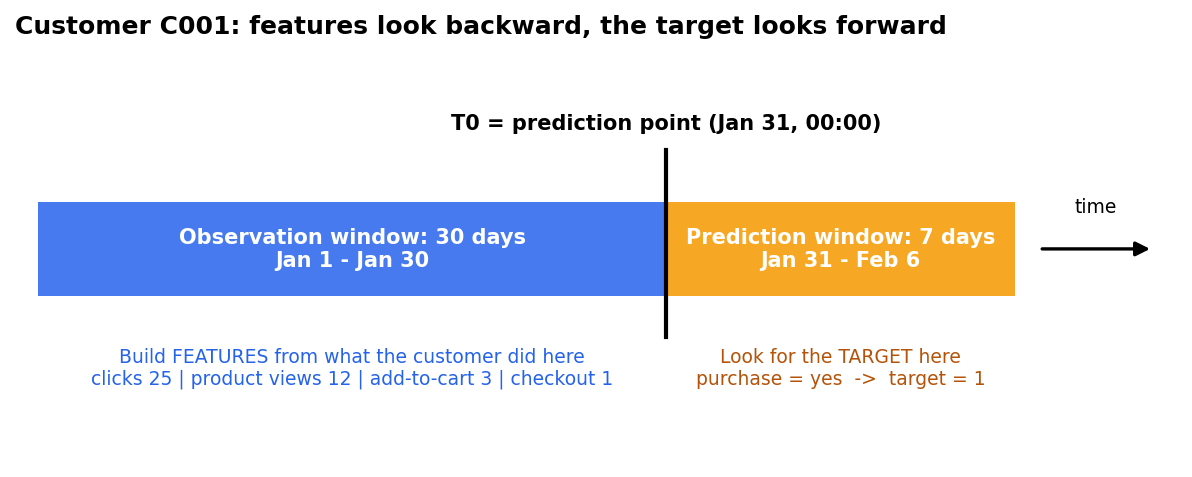

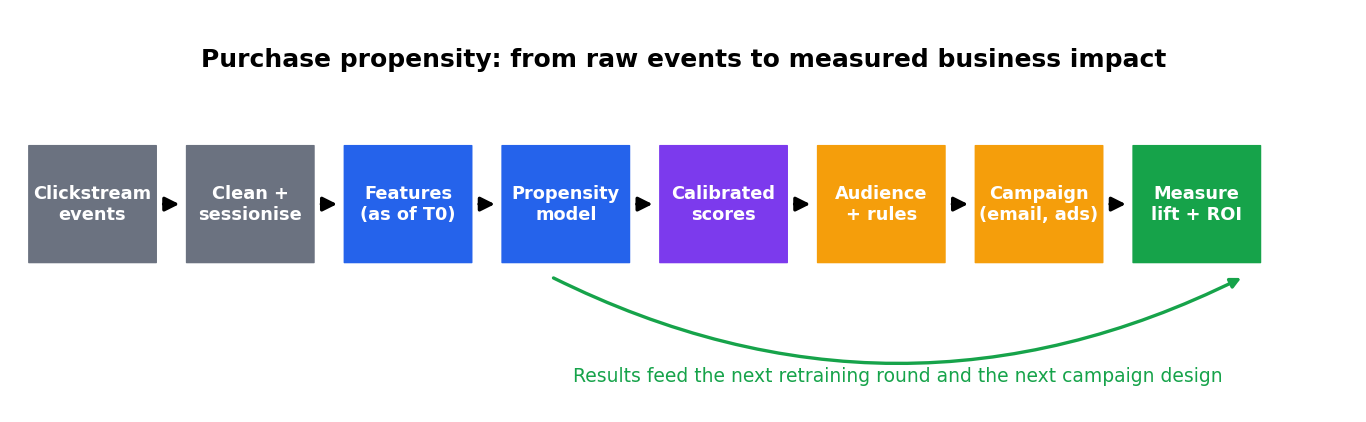

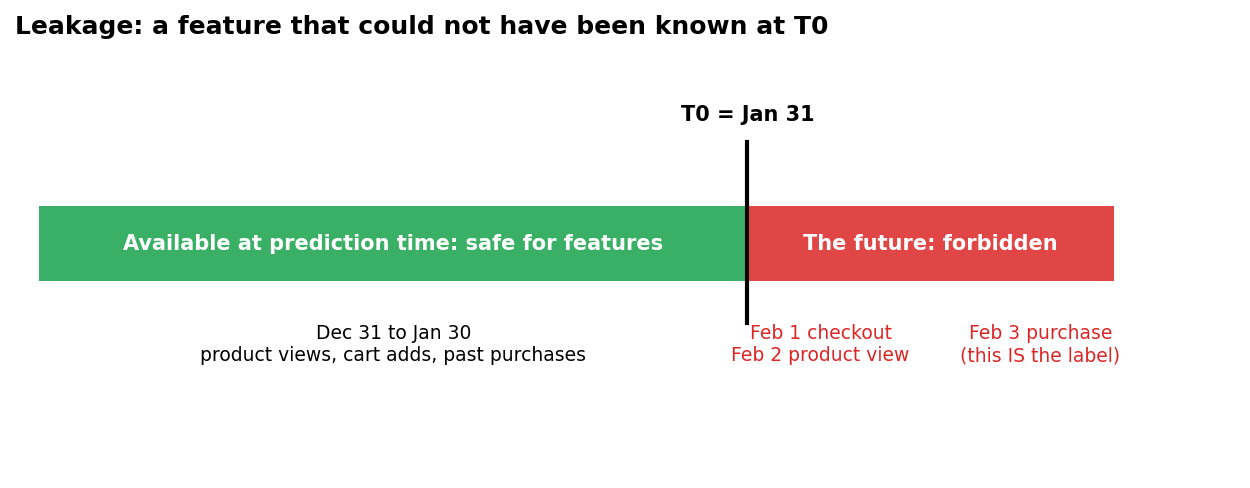

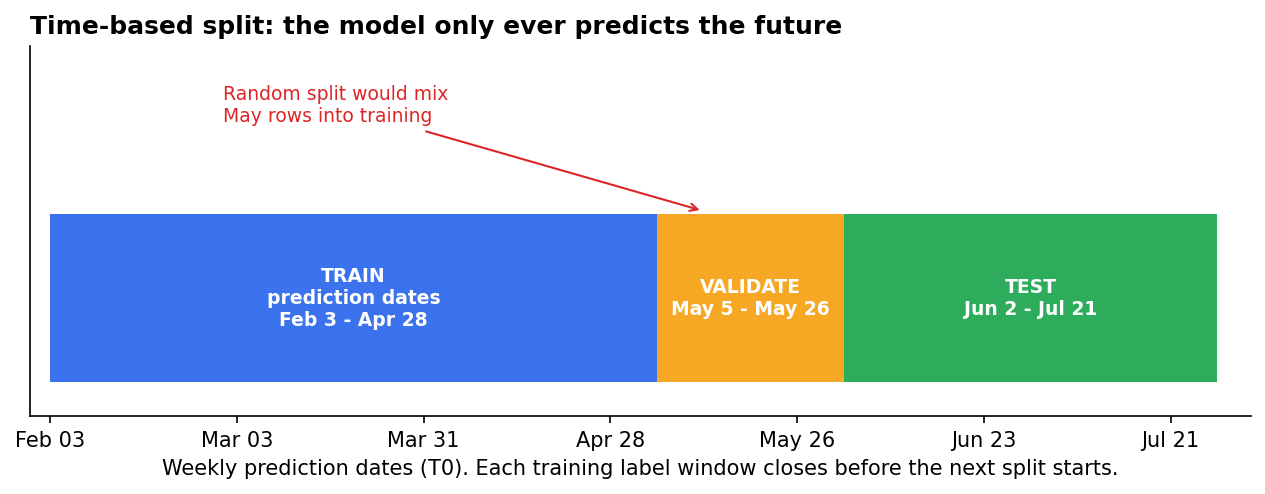

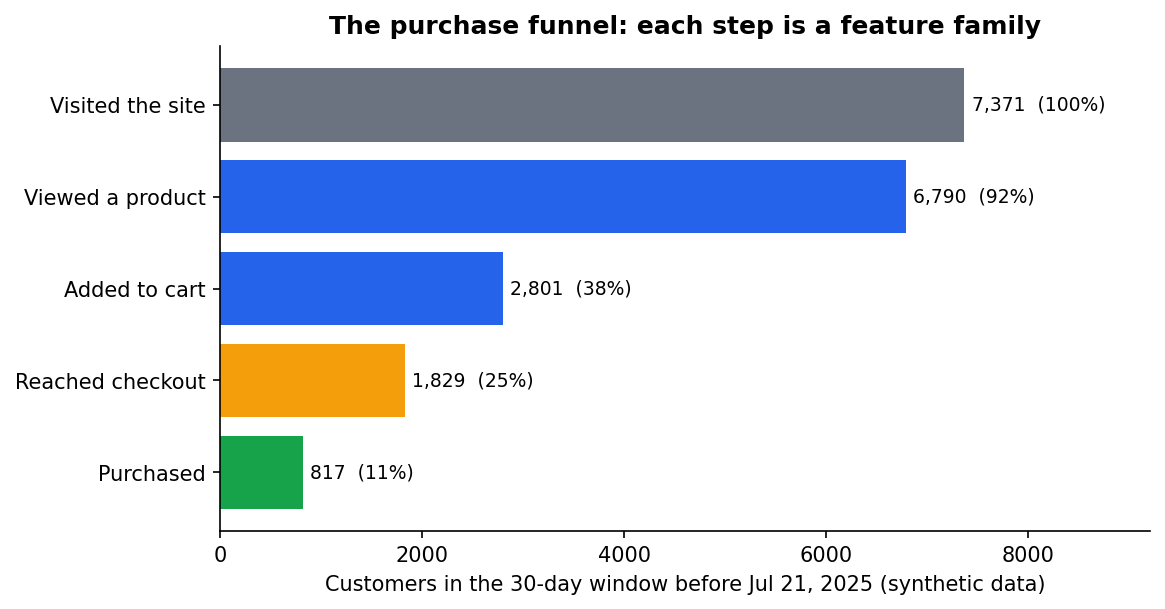

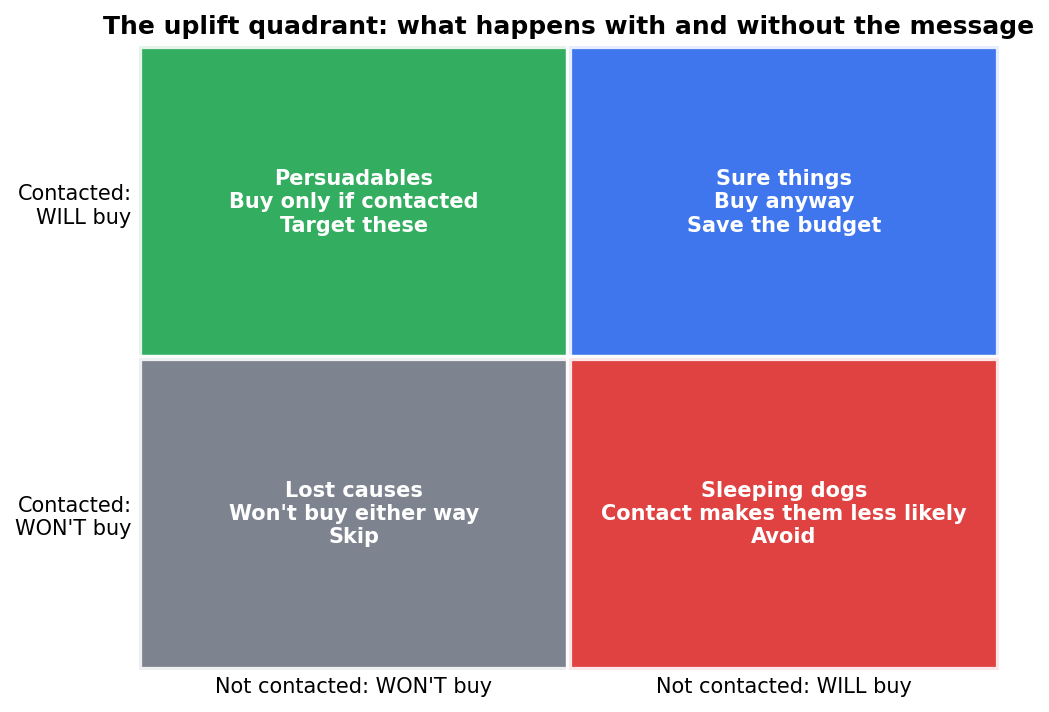

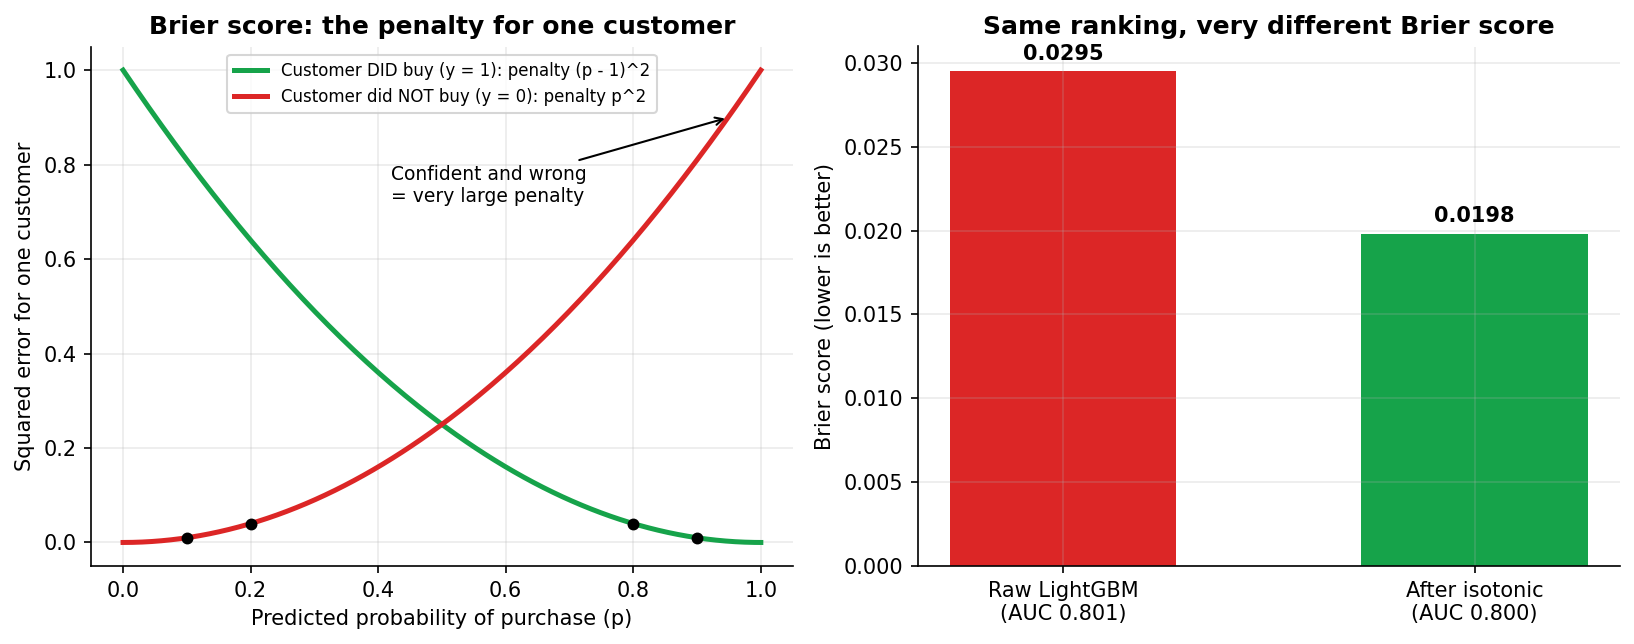

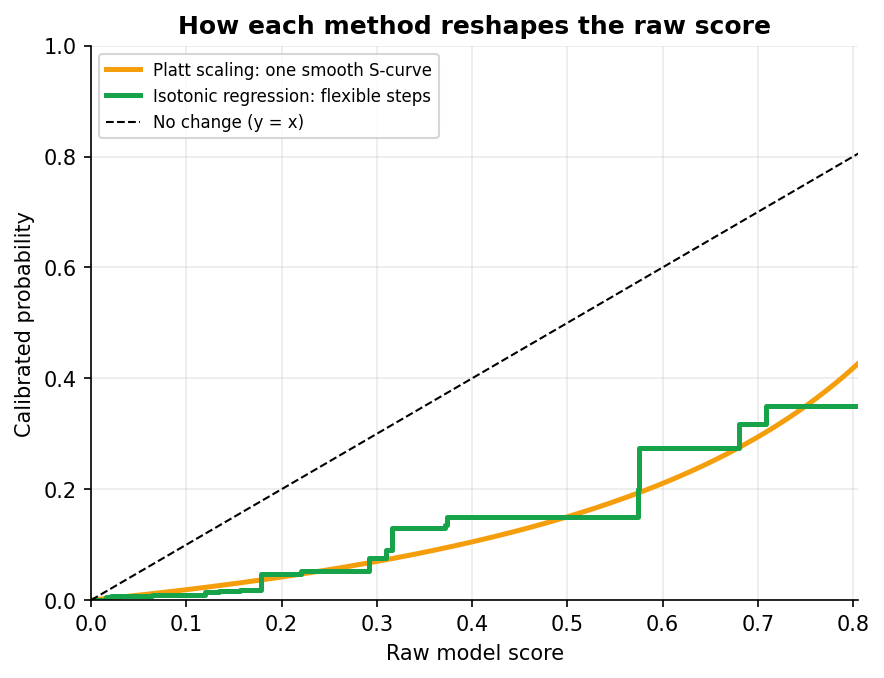

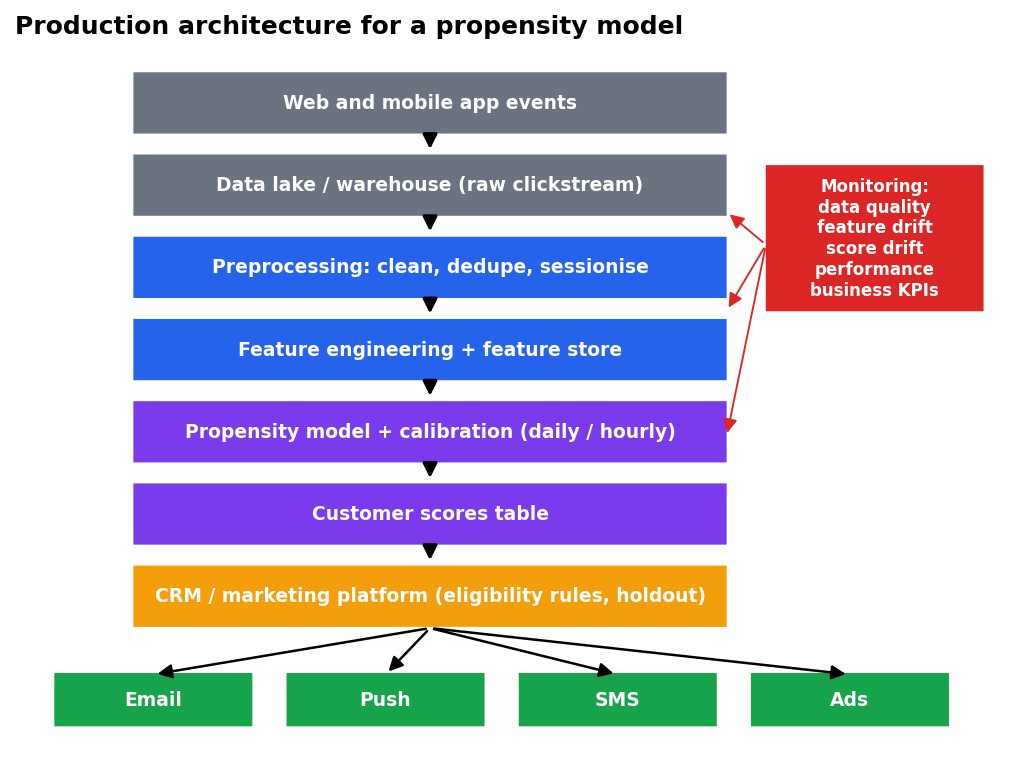

In [46]:
for n in ["ppm-01-observation-prediction-windows","ppm-02-pipeline-overview","ppm-18-leakage-timeline","ppm-04-time-based-split","ppm-03-clickstream-funnel","ppm-08-propensity-vs-uplift-quadrant","ppm-14-brier-score-explained","ppm-15-platt-vs-isotonic-mapping","ppm-09-production-architecture"]:
    show_img(n + ".png", 800)

## Save this notebook to GitHub
1. Make sure every cell above has run and shows its output.
2. Choose *File > Save a copy in GitHub* and pick your `purchase-propensity-model` repo. Put it in the `notebooks/` folder.
3. Alternatively choose *File > Download > .ipynb* and upload the file through the GitHub web page (*Add file > Upload files*).

All data in this notebook is synthetic. Results will differ slightly across library versions.